In [1]:
# ============================================================
# SECTION 1 — IMPORTS & CONFIGURATION
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import warnings
import os
import gc
import pickle
import joblib

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.4f}".format)

# ── Sklearn ──────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler, QuantileTransformer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score, silhouette_samples,
    davies_bouldin_score, calinski_harabasz_score,
    adjusted_rand_score
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors

# ── Hiérarchique ─────────────────────────────────────────────
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

# ── HDBSCAN ──────────────────────────────────────────────────
import hdbscan

# ── Interprétabilité ─────────────────────────────────────────
import shap
import lime
import lime.lime_tabular

# ── MLflow ───────────────────────────────────────────────────
import mlflow
import mlflow.sklearn
from mlflow.models.signature import infer_signature

# ============================================================
# CONFIGURATION GLOBALE
# ============================================================
RANDOM_STATE = 42
K_MIN, K_MAX = 4, 6
K_RANGE      = range(K_MIN, K_MAX + 1)
N_SLOW       = 20_000   # échantillon pour CAH/HDBSCAN
N_DBSCAN     = 15_000   # échantillon pour DBSCAN

os.makedirs("models",   exist_ok=True)
os.makedirs("figures",  exist_ok=True)
os.makedirs("reports",  exist_ok=True)

# ── MLflow local ─────────────────────────────────────────────
# Lancez dans un terminal : mlflow ui --port 5000
# Puis ouvrez              : http://localhost:5000
mlflow.set_tracking_uri("mlruns")
mlflow.set_experiment("olist_segmentation_v2")

print("✅ Imports OK")
print(f"   K_RANGE     : {list(K_RANGE)}")
print(f"   RANDOM_STATE: {RANDOM_STATE}")

Traceback (most recent call last):
  File "C:\Users\CFAC\AppData\Roaming\Python\Python313\site-packages\mlflow\store\tracking\file_store.py", line 383, in search_experiments
    exp = self._get_experiment(exp_id, view_type)
  File "C:\Users\CFAC\AppData\Roaming\Python\Python313\site-packages\mlflow\store\tracking\file_store.py", line 481, in _get_experiment
    meta = FileStore._read_yaml(experiment_dir, FileStore.META_DATA_FILE_NAME)
  File "C:\Users\CFAC\AppData\Roaming\Python\Python313\site-packages\mlflow\store\tracking\file_store.py", line 1670, in _read_yaml
    return _read_helper(root, file_name, attempts_remaining=retries)
  File "C:\Users\CFAC\AppData\Roaming\Python\Python313\site-packages\mlflow\store\tracking\file_store.py", line 1663, in _read_helper
    result = read_yaml(root, file_name)
  File "C:\Users\CFAC\AppData\Roaming\Python\Python313\site-packages\mlflow\utils\yaml_utils.py", line 104, in read_yaml
    raise MissingConfigException(f"Yaml file '{file_path}' does n

✅ Imports OK
   K_RANGE     : [4, 5, 6]
   RANDOM_STATE: 42


In [2]:
# ============================================================
# SECTION 2 — CHARGEMENT DES DONNÉES
# ============================================================
client_df = pd.read_csv("Base.csv", low_memory=False)

print(f"Shape : {client_df.shape}")
print(f"\nTypes :\n{client_df.dtypes.value_counts()}")
print(f"\nNaN :\n{client_df.isna().sum()[client_df.isna().sum() > 0]}")
client_df.head()

Shape : (93358, 47)

Types :
float64    43
object      4
Name: count, dtype: int64

NaN :
Series([], dtype: int64)


,customer_unique_id,Recency,Frequency,Monetary,avg_delivery_days,late_delivery_rate,avg_delivery_delta,preferred_payment,avg_installments,product_diversity,avg_order_value,avg_freight_value,preferred_category,avg_lat,avg_lng,avg_freight_ratio,std_freight_ratio,review_participation_rate,cancellation_rate,avg_review_score_full,has_full_review,avg_review_score_available,has_available_review,has_delivered_orders,has_cancelled_orders,avg_basket_size,first_purchase_category,first_purchase_value,inter_purchase_time,dissatisfaction_rate_proxy,avg_seller_rating,payment_type_diversity,"spend_('price', 'electronics')","spend_('price', 'health_beauty')","spend_('price', 'home')","spend_('price', 'other')","spend_('price', 'sports_leisure')",dist_sao_paulo,recency_ratio,CLV_estimate,is_repeat_customer,has_delivery,never_delivered,has_review,has_delivery_info,most_frequent_purchase_hour,most_frequent_purchase_day
0,0000366f3b9a7992bf8c76cfdf3221e2,161.0000,1.0000,141.9000,6.0000,0.0000,4.0000,credit_card,8.0000,1.0000,129.9000,12.0000,home,-23.3403,-46.8311,0.0846,0.0000,1.0000,0.0000,5.0000,1.0000,5.0000,1.0000,1.0000,0.0000,1.0000,home,141.9000,42.0000,0.0000,4.1816,1.0000,0.0000,0.0000,129.9000,0.0000,0.0000,31.0599,0.2085,67.1360,0.0000,1.0000,0.0000,1.0000,1.0000,10.0000,0.0000
1,0000b849f77a49e4a4ce2b2a4ca5be3f,164.0000,1.0000,27.1900,3.0000,0.0000,4.0000,credit_card,1.0000,1.0000,18.9000,8.2900,health_beauty,-23.5590,-46.7885,0.3049,0.0000,1.0000,0.0000,4.0000,1.0000,4.0000,1.0000,1.0000,0.0000,1.0000,health_beauty,27.1900,42.0000,0.0000,4.0816,1.0000,0.0000,18.9000,0.0000,0.0000,0.0000,16.1889,0.2124,12.8642,0.0000,1.0000,0.0000,1.0000,1.0000,10.0000,0.0000
2,0000f46a3911fa3c0805444483337064,586.0000,1.0000,86.2200,25.0000,0.0000,1.0000,credit_card,8.0000,1.0000,69.0000,17.2200,office,-27.5430,-48.6349,0.1997,0.0000,1.0000,0.0000,3.0000,1.0000,3.0000,1.0000,1.0000,0.0000,1.0000,office,86.2200,42.0000,0.0000,4.1918,1.0000,0.0000,0.0000,0.0000,69.0000,0.0000,487.4106,0.7591,40.7926,0.0000,1.0000,0.0000,1.0000,1.0000,10.0000,0.0000
3,0000f6ccb0745a6a4b88665a16c9f078,370.0000,1.0000,43.6200,20.0000,0.0000,11.0000,credit_card,4.0000,1.0000,25.9900,17.6300,electronics,-1.3127,-48.4827,0.4042,0.0000,1.0000,0.0000,4.0000,1.0000,4.0000,1.0000,1.0000,0.0000,1.0000,electronics,43.6200,42.0000,0.0000,3.9618,1.0000,25.9900,0.0000,0.0000,0.0000,0.0000,2480.7288,0.4793,20.6376,0.0000,1.0000,0.0000,1.0000,1.0000,10.0000,0.0000
4,0004aac84e0df4da2b147fca70cf8255,337.0000,1.0000,196.8900,13.0000,0.0000,7.0000,credit_card,6.0000,1.0000,180.0000,16.8900,electronics,-23.5056,-47.4698,0.0858,0.0000,1.0000,0.0000,5.0000,1.0000,5.0000,1.0000,1.0000,0.0000,1.0000,electronics,196.8900,42.0000,0.0000,3.8129,1.0000,180.0000,0.0000,0.0000,0.0000,0.0000,85.7627,0.4365,93.1529,0.0000,1.0000,0.0000,1.0000,1.0000,10.0000,0.0000


In [3]:
client_df.columns

Index(['customer_unique_id', 'Recency', 'Frequency', 'Monetary',
       'avg_delivery_days', 'late_delivery_rate', 'avg_delivery_delta',
       'preferred_payment', 'avg_installments', 'product_diversity',
       'avg_order_value', 'avg_freight_value', 'preferred_category', 'avg_lat',
       'avg_lng', 'avg_freight_ratio', 'std_freight_ratio',
       'review_participation_rate', 'cancellation_rate',
       'avg_review_score_full', 'has_full_review',
       'avg_review_score_available', 'has_available_review',
       'has_delivered_orders', 'has_cancelled_orders', 'avg_basket_size',
       'first_purchase_category', 'first_purchase_value',
       'inter_purchase_time', 'dissatisfaction_rate_proxy',
       'avg_seller_rating', 'payment_type_diversity',
       'spend_('price', 'electronics')', 'spend_('price', 'health_beauty')',
       'spend_('price', 'home')', 'spend_('price', 'other')',
       'spend_('price', 'sports_leisure')', 'dist_sao_paulo', 'recency_ratio',
       'CLV_estimate'


VARIABLES ACTIVES — ACP & CLUSTERING

Nombre de variables : 5

Variables retenues :

✔ Recency
✔ avg_review_score_full
✔ avg_delivery_days
✔ avg_installments
✔ CLV_estimate

TYPES
Recency                  float64
avg_review_score_full    float64
avg_delivery_days        float64
avg_installments         float64
CLV_estimate             float64
dtype: object

VALEURS MANQUANTES
Recency                  0
avg_review_score_full    0
avg_delivery_days        0
avg_installments         0
CLV_estimate             0
dtype: int64

✅ Aucun NaN

STATISTIQUES DESCRIPTIVES


,count,mean,std,min,25%,50%,75%,max
Recency,93358.0000,287.1050,152.5920,50.0000,164.0000,268.0000,395.0000,763.0000
avg_review_score_full,93358.0000,4.1590,1.2780,1.0000,4.0000,5.0000,5.0000,5.0000
avg_delivery_days,93358.0000,12.1010,9.5520,0.0000,6.0000,10.0000,15.0000,209.0000
avg_installments,93358.0000,2.9150,2.6910,0.0000,1.0000,2.0000,4.0000,24.0000
CLV_estimate,93358.0000,83.5030,133.4220,0.0000,29.8540,51.2960,88.4500,8811.2490



CORRÉLATIONS > 0.65
✅ Aucune corrélation problématique


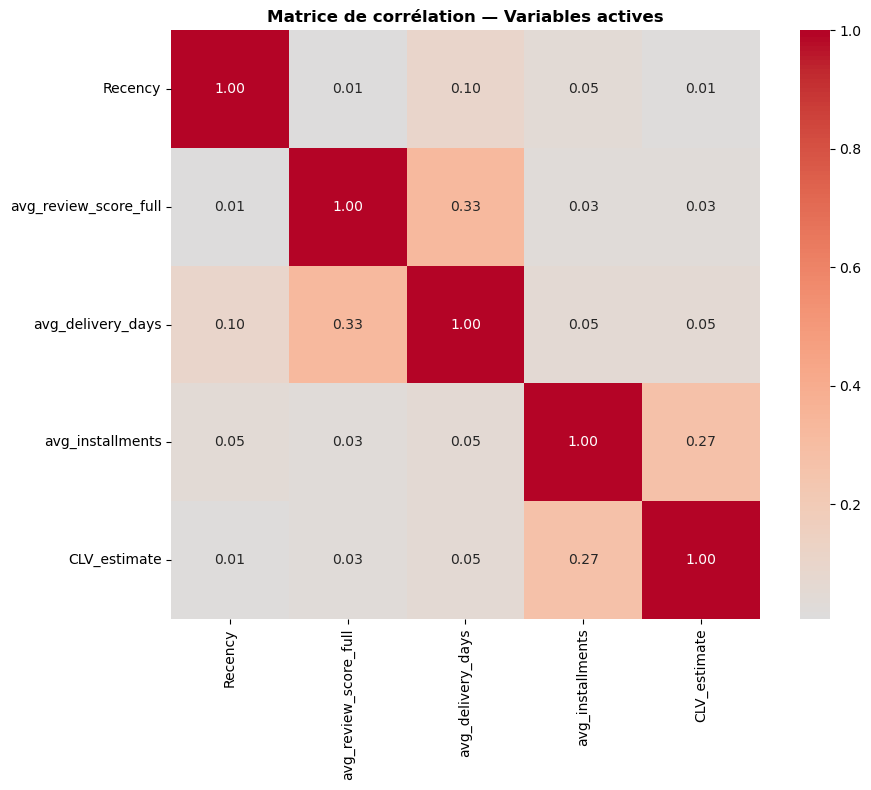


DISTRIBUTIONS


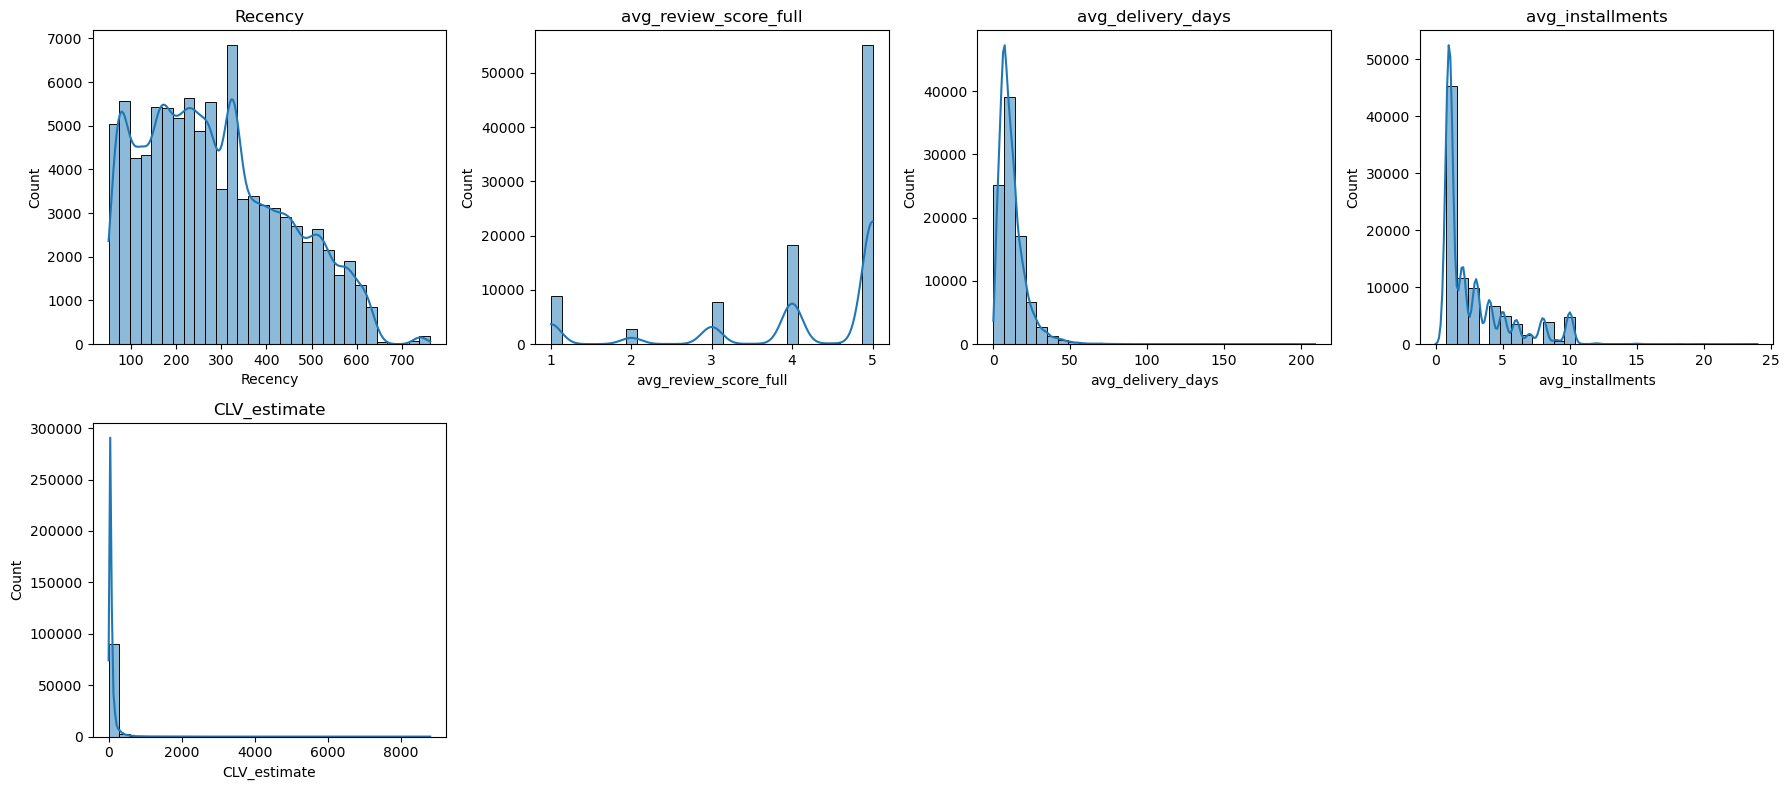


APERÇU


,Recency,avg_review_score_full,avg_delivery_days,avg_installments,CLV_estimate
0,161.0000,5.0000,6.0000,8.0000,67.1360
1,164.0000,4.0000,3.0000,1.0000,12.8642
2,586.0000,3.0000,25.0000,8.0000,40.7926
3,370.0000,4.0000,20.0000,4.0000,20.6376
4,337.0000,5.0000,13.0000,6.0000,93.1529



Shape final : (93358, 5)


In [4]:
# ============================================================
# SECTION 3 — VARIABLES FINALES POUR ACP & CLUSTERING
# VERSION OPTIMISÉE OLIST
# ============================================================

# Objectif :
# - éviter les variables redondantes
# - éviter les variables quasi constantes
# - améliorer la séparation des clusters
# - améliorer l'interprétabilité métier
# - obtenir une ACP plus stable

# ============================================================
# VARIABLES ACTIVES (UTILISÉES POUR ACP + CLUSTERING)
# ============================================================

FEATURES_ACTIVE = [

    # --------------------------------------------------------
    # RFM
    # --------------------------------------------------------

    "Recency",

   # "Monetary",

    # --------------------------------------------------------
    # SATISFACTION CLIENT
    # --------------------------------------------------------

    "avg_review_score_full",

    # --------------------------------------------------------
    # LOGISTIQUE / LIVRAISON
    # --------------------------------------------------------

    "avg_delivery_days",

    # --------------------------------------------------------
    # COMPORTEMENT DE PAIEMENT
    # --------------------------------------------------------

    "avg_installments",

    # --------------------------------------------------------
    # DIVERSITÉ PRODUITS
    # --------------------------------------------------------

   # "product_diversity",

    # --------------------------------------------------------
    # VALEUR CLIENT LONG TERME
    # --------------------------------------------------------

    "CLV_estimate",

    # --------------------------------------------------------
    # TEMPS ENTRE ACHATS
    # --------------------------------------------------------

  #  "inter_purchase_time"

]

# ============================================================
# VARIABLES SUPPLÉMENTAIRES
# (POUR LE PROFILING UNIQUEMENT)
# ============================================================

FEATURES_SUPPLEMENTARY = [

    # --------------------------------------------------------
    # CATÉGORIES
    # --------------------------------------------------------

    "preferred_payment",

    "preferred_category",

    "first_purchase_category",

    # --------------------------------------------------------
    # GÉOGRAPHIE
    # --------------------------------------------------------

    "avg_lat",

    "avg_lng",

    "dist_sao_paulo",

    # --------------------------------------------------------
    # TEMPS D'ACHAT
    # --------------------------------------------------------

    "most_frequent_purchase_hour",

    "most_frequent_purchase_day",

    # --------------------------------------------------------
    # VARIABLES BINAIRES
    # --------------------------------------------------------

    "is_repeat_customer",

    "has_review",

    "has_delivery",

    "has_cancelled_orders",

    # --------------------------------------------------------
    # LOGISTIQUE
    # --------------------------------------------------------

    "late_delivery_rate",

    "avg_delivery_delta",

    "avg_freight_ratio",

    # --------------------------------------------------------
    # SATISFACTION
    # --------------------------------------------------------

    "review_participation_rate",

    "dissatisfaction_rate_proxy",

    "avg_seller_rating"

]

# ============================================================
# MATRICE ACP / CLUSTERING
# ============================================================

X_raw = client_df[
    FEATURES_ACTIVE
].copy()

# ============================================================
# INFORMATIONS GÉNÉRALES
# ============================================================

print("\n" + "=" * 70)
print("VARIABLES ACTIVES — ACP & CLUSTERING")
print("=" * 70)

print(
    f"\nNombre de variables : "
    f"{len(FEATURES_ACTIVE)}"
)

print("\nVariables retenues :\n")

for v in FEATURES_ACTIVE:

    print(f"✔ {v}")

# ============================================================
# TYPES
# ============================================================

print("\n" + "=" * 70)
print("TYPES")
print("=" * 70)

print(
    X_raw.dtypes
)

# ============================================================
# VALEURS MANQUANTES
# ============================================================

print("\n" + "=" * 70)
print("VALEURS MANQUANTES")
print("=" * 70)

na_counts = X_raw.isna().sum()

print(na_counts)

if na_counts.sum() == 0:

    print("\n✅ Aucun NaN")

else:

    print(
        f"\n⚠ {na_counts.sum()} valeurs manquantes"
    )

# ============================================================
# STATISTIQUES
# ============================================================

print("\n" + "=" * 70)
print("STATISTIQUES DESCRIPTIVES")
print("=" * 70)

display(

    X_raw
    .describe()
    .T
    .round(3)
)

# ============================================================
# CORRÉLATIONS
# ============================================================

print("\n" + "=" * 70)
print("CORRÉLATIONS > 0.65")
print("=" * 70)

corr = X_raw.corr(
    numeric_only=True
).abs()

found = False

for i in range(len(corr.columns)):

    for j in range(i + 1, len(corr.columns)):

        val = corr.iloc[i, j]

        if val > 0.65:

            print(

                f"⚠ {corr.columns[i]} "
                f"↔ "
                f"{corr.columns[j]} "
                f"r={val:.3f}"
            )

            found = True

if not found:

    print(
        "✅ Aucune corrélation problématique"
    )

# ============================================================
# HEATMAP CORRÉLATION
# ============================================================

plt.figure(
    figsize=(10, 8)
)

sns.heatmap(

    corr,

    annot=True,

    fmt=".2f",

    cmap="coolwarm",

    center=0,

    square=True
)

plt.title(

    "Matrice de corrélation — Variables actives",

    fontweight="bold"
)

plt.tight_layout()

plt.show()

# ============================================================
# DISTRIBUTIONS
# ============================================================

print("\n" + "=" * 70)
print("DISTRIBUTIONS")
print("=" * 70)

fig, axes = plt.subplots(

    nrows=2,

    ncols=4,

    figsize=(18, 8)
)

axes = axes.flatten()

for i, col in enumerate(FEATURES_ACTIVE):

    sns.histplot(

        X_raw[col],

        bins=30,

        kde=True,

        ax=axes[i]
    )

    axes[i].set_title(col)

# Suppression axes vides
for j in range(i + 1, len(axes)):

    fig.delaxes(axes[j])

plt.tight_layout()

plt.show()

# ============================================================
# APERÇU
# ============================================================

print("\n" + "=" * 70)
print("APERÇU")
print("=" * 70)

display(

    X_raw.head()
)

# ============================================================
# SHAPE FINAL
# ============================================================

print("\n" + "=" * 70)

print(
    f"Shape final : {X_raw.shape}"
)

print("=" * 70)

=== NaN par variable ===
Recency                  0
avg_review_score_full    0
avg_delivery_days        0
avg_installments         0
CLV_estimate             0
dtype: int64

✅ Aucun NaN


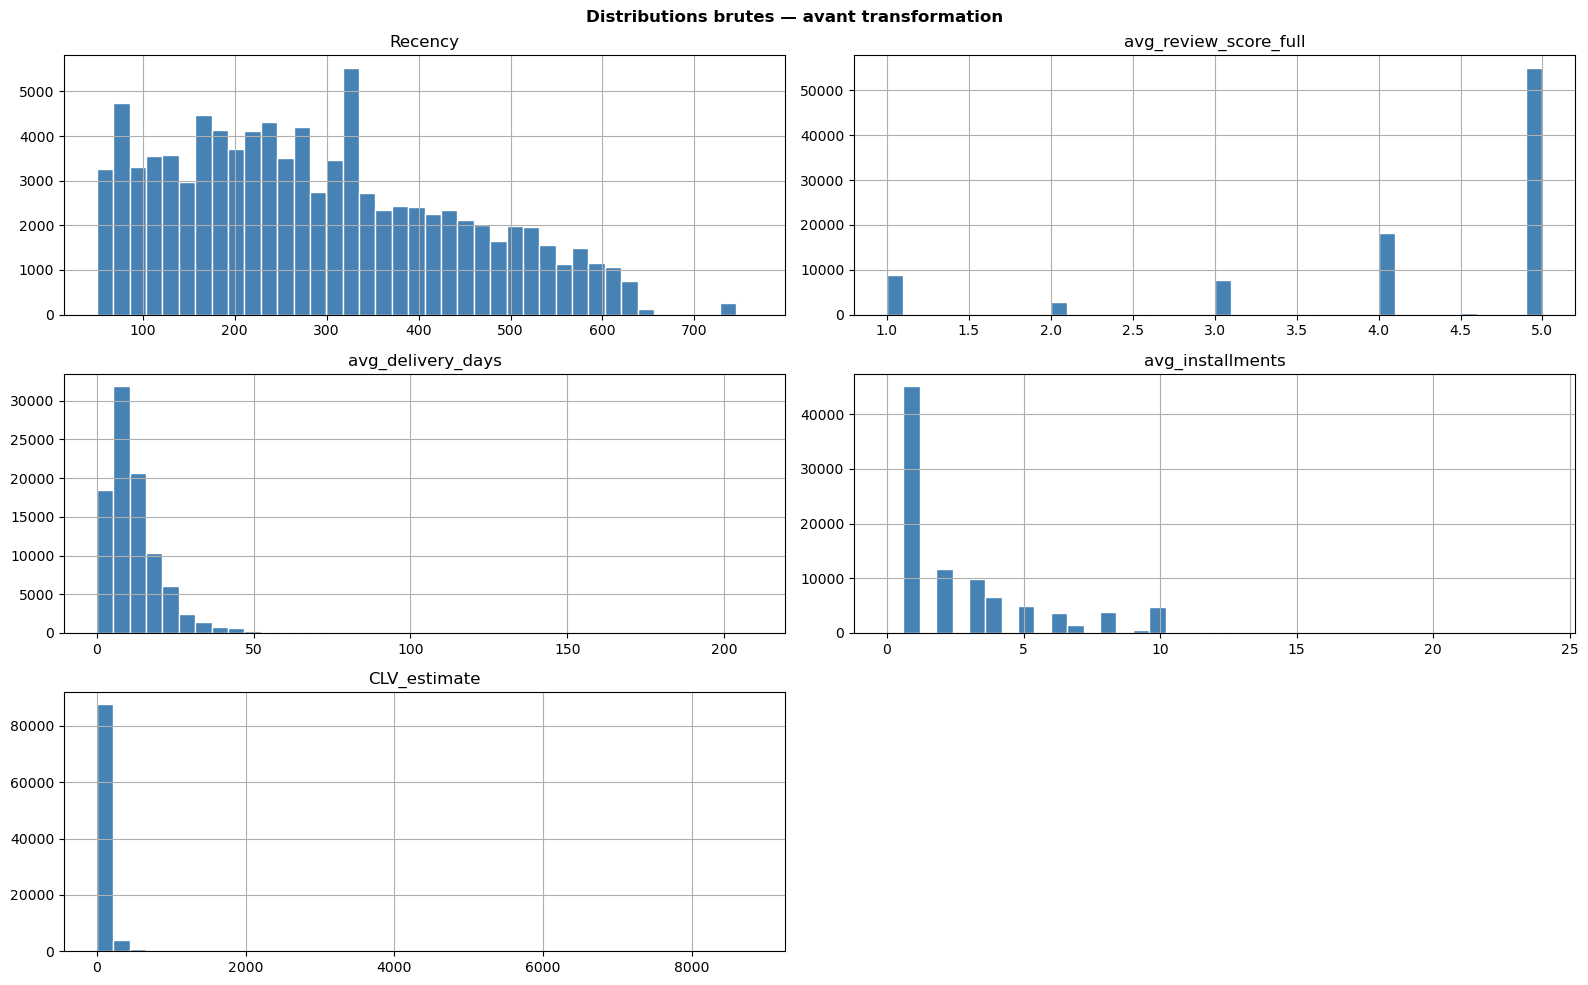

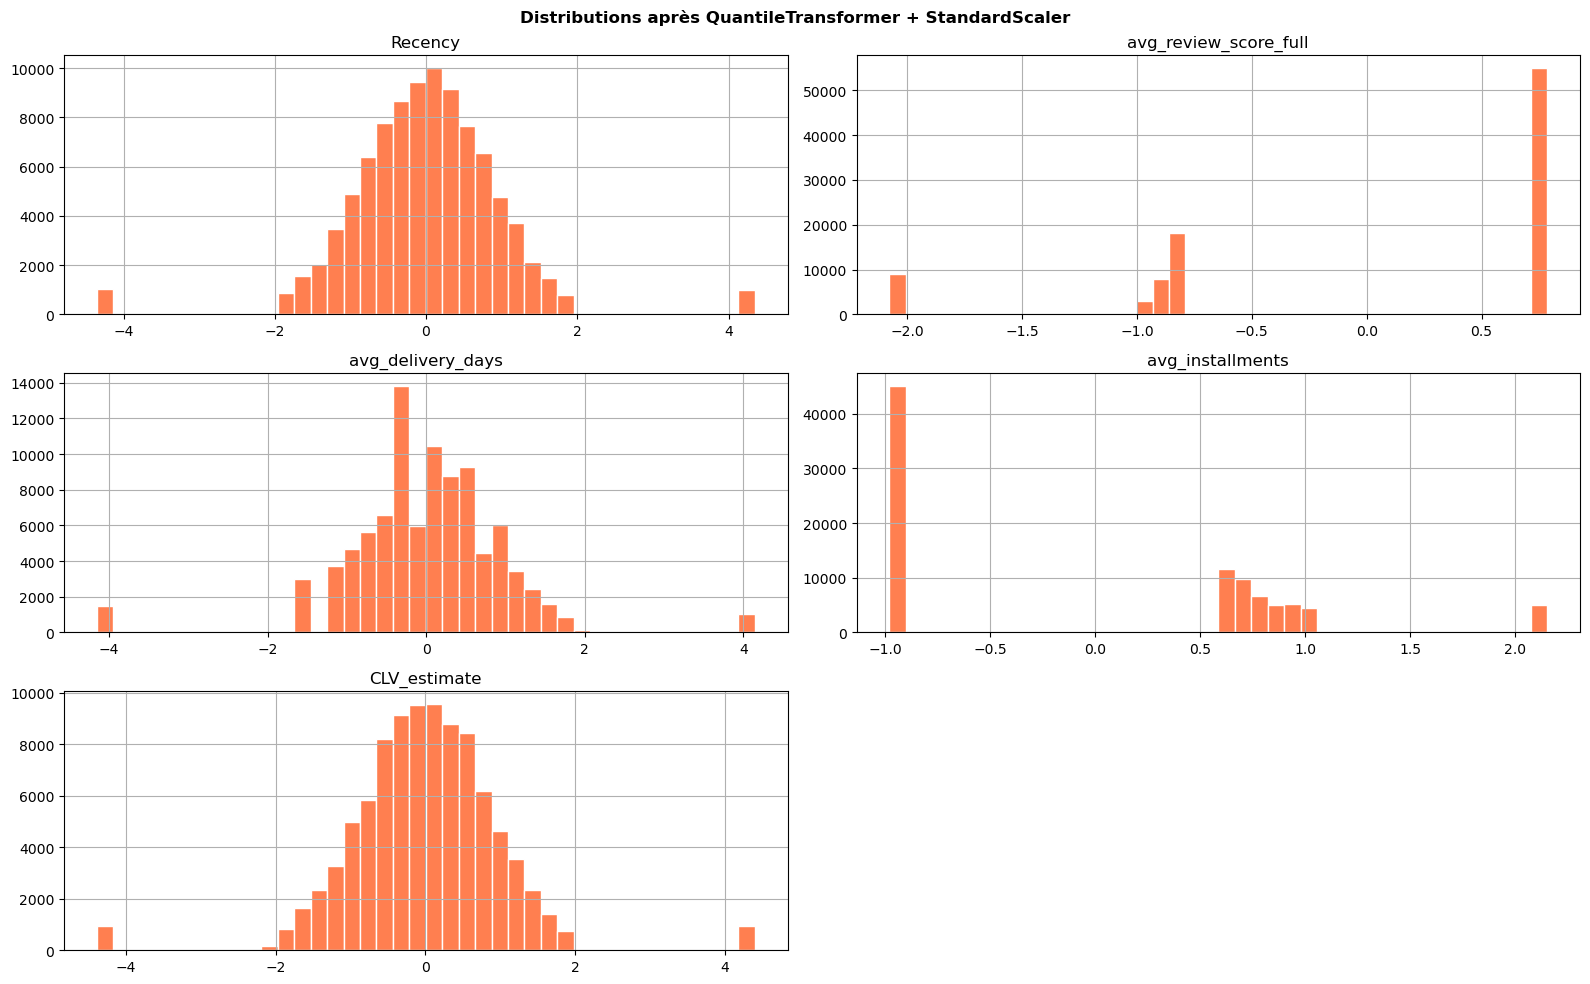

✅ X_scaled shape : (93358, 5)
   Écart-types (tous ≈ 1.0) : min=1.000 max=1.000


['models/scaler.pkl']

In [5]:
# ============================================================
# SECTION 4 — VALEURS MANQUANTES + DISTRIBUTIONS
# ============================================================
print("=== NaN par variable ===")
print(X_raw.isna().sum())

# Imputation par médiane
for col in X_raw.columns:
    X_raw[col] = X_raw[col].fillna(X_raw[col].median())

assert X_raw.isna().sum().sum() == 0, "❌ NaN résiduels"
print("\n✅ Aucun NaN")

# Distributions avant transformation
X_raw.hist(figsize=(16, 10), bins=40, color="steelblue", edgecolor="white")
plt.suptitle("Distributions brutes — avant transformation", fontweight="bold")
plt.tight_layout()
plt.savefig("figures/00_distributions_brutes.png", dpi=100, bbox_inches="tight")
plt.show(); plt.close()

# ============================================================
# SECTION 4b — WINSORISATION (cap 1%–99%)
# ============================================================
def cap_outliers(df, cols, q_low=0.01, q_high=0.99):
    df = df.copy()
    for col in cols:
        df[col] = df[col].clip(
            lower=df[col].quantile(q_low),
            upper=df[col].quantile(q_high)
        )
    return df

X_raw = cap_outliers(X_raw, FEATURES_ACTIVE)

# ============================================================
# SECTION 4c — QUANTILE TRANSFORMER (→ distribution normale)
# ============================================================
# QuantileTransformer normalise les distributions asymétriques
# et réduit l'impact des outliers résiduels.
# C'est la transformation recommandée pour les données RFM.

qt = QuantileTransformer(
    output_distribution="normal",
    n_quantiles=min(1000, len(X_raw)),
    random_state=RANDOM_STATE
)
X_qt = qt.fit_transform(X_raw)
X_qt = pd.DataFrame(X_qt, columns=FEATURES_ACTIVE)

# ============================================================
# SECTION 4d — STANDARDISATION
# ============================================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_qt)
X_scaled = pd.DataFrame(X_scaled, columns=FEATURES_ACTIVE)

# Distributions après transformation
X_scaled.hist(figsize=(16, 10), bins=40, color="coral", edgecolor="white")
plt.suptitle("Distributions après QuantileTransformer + StandardScaler",
             fontweight="bold")
plt.tight_layout()
plt.savefig("figures/00b_distributions_transformees.png", dpi=100, bbox_inches="tight")
plt.show(); plt.close()

print(f"✅ X_scaled shape : {X_scaled.shape}")
print(f"   Écart-types (tous ≈ 1.0) : min={X_scaled.std().min():.3f} "
      f"max={X_scaled.std().max():.3f}")

# Sauvegarde pipeline preprocessing
joblib.dump(qt,     "models/quantile_transformer.pkl")
joblib.dump(scaler, "models/scaler.pkl")

=== Variance expliquée par composante ===
  PC 1 : 0.293  cumulée=0.293  █████████████████
  PC 2 : 0.240  cumulée=0.534  ██████████████
  PC 3 : 0.196  cumulée=0.730  ███████████
  PC 4 : 0.147  cumulée=0.877  ████████
  PC 5 : 0.123  cumulée=1.000  ███████

PC1 capte : 29.3%  ✅ Bonne répartition — whitening recommandé
  70% variance → 3 composantes
  80% variance → 4 composantes
  85% variance → 4 composantes
  90% variance → 5 composantes


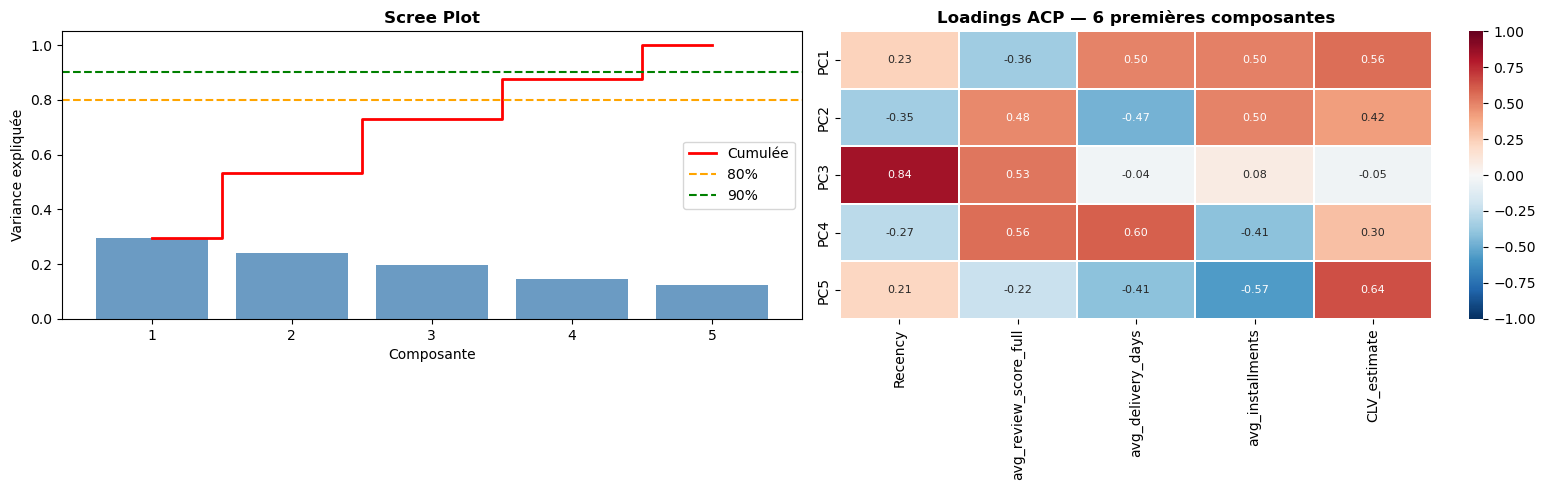


=== Axes dominants (|loading| > 0.30) ===
  PC1 : CLV_estimate(+0.56), avg_installments(+0.50), avg_delivery_days(+0.50), avg_review_score_full(-0.36)
  PC2 : avg_installments(+0.50), avg_review_score_full(+0.48), avg_delivery_days(-0.47), CLV_estimate(+0.42), Recency(-0.35)
  PC3 : Recency(+0.84), avg_review_score_full(+0.53)
  PC4 : avg_delivery_days(+0.60), avg_review_score_full(+0.56), avg_installments(-0.41), CLV_estimate(+0.30)
  PC5 : CLV_estimate(+0.64), avg_installments(-0.57), avg_delivery_days(-0.41)

→ N_COMP retenu (85% variance) : 4
X_pca    : (93358, 4)
X_pca_2d : (93358, 2)


60913

In [6]:
# ============================================================
# SECTION 5 — ACP DIAGNOSTIQUE
# ============================================================
pca_diag = PCA(n_components=len(FEATURES_ACTIVE), random_state=RANDOM_STATE)
pca_diag.fit(X_scaled)
cumvar   = np.cumsum(pca_diag.explained_variance_ratio_)

print("=== Variance expliquée par composante ===")
for i, (ev, cv) in enumerate(zip(pca_diag.explained_variance_ratio_, cumvar)):
    bar  = "█" * int(ev * 60)
    print(f"  PC{i+1:2d} : {ev:.3f}  cumulée={cv:.3f}  {bar}")

pc1_share = pca_diag.explained_variance_ratio_[0]
print(f"\nPC1 capte : {pc1_share*100:.1f}%", end="  ")
if pc1_share < 0.25:
    print("✅ Excellente répartition")
elif pc1_share < 0.35:
    print("✅ Bonne répartition — whitening recommandé")
else:
    print("⚠️  Répartition modérée — whitening obligatoire")

for s in [0.70, 0.80, 0.85, 0.90]:
    n = int(np.argmax(cumvar >= s)) + 1
    print(f"  {s*100:.0f}% variance → {n} composantes")

# ── Scree plot ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(range(1, len(pca_diag.explained_variance_ratio_)+1),
            pca_diag.explained_variance_ratio_, color="steelblue", alpha=0.8)
axes[0].step(range(1, len(cumvar)+1), cumvar,
             where="mid", color="red", lw=2, label="Cumulée")
axes[0].axhline(0.80, color="orange", ls="--", lw=1.5, label="80%")
axes[0].axhline(0.90, color="green",  ls="--", lw=1.5, label="90%")
axes[0].set_xlabel("Composante"); axes[0].set_ylabel("Variance expliquée")
axes[0].set_title("Scree Plot", fontweight="bold"); axes[0].legend()

# ── Heatmap loadings ─────────────────────────────────────────
n_pc_show = min(6, len(FEATURES_ACTIVE))
loadings  = pd.DataFrame(
    pca_diag.components_[:n_pc_show],
    columns=FEATURES_ACTIVE,
    index=[f"PC{i+1}" for i in range(n_pc_show)]
)
sns.heatmap(loadings, annot=True, fmt=".2f", cmap="RdBu_r",
            vmin=-1, vmax=1, lw=0.3, ax=axes[1], annot_kws={"size": 8})
axes[1].set_title("Loadings ACP — 6 premières composantes", fontweight="bold")

plt.tight_layout()
plt.savefig("figures/01_acp.png", dpi=100, bbox_inches="tight")
plt.show(); plt.close()

# ── Interprétation des axes ───────────────────────────────────
print("\n=== Axes dominants (|loading| > 0.30) ===")
for pc in loadings.index:
    row = loadings.loc[pc]
    dom = row[row.abs() > 0.30].sort_values(key=abs, ascending=False)
    if len(dom):
        vars_str = ", ".join([f"{f}({v:+.2f})" for f, v in dom.items()])
        mono = "  ⚠️ MONO-VARIABLE" if len(dom) == 1 else ""
        print(f"  {pc} : {vars_str}{mono}")

# ── ACP finale pour clustering ────────────────────────────────
N_COMP = int(np.argmax(cumvar >= 0.85)) + 1
print(f"\n→ N_COMP retenu (85% variance) : {N_COMP}")

pca_final = PCA(n_components=N_COMP, whiten=True, random_state=RANDOM_STATE)
X_pca     = pca_final.fit_transform(X_scaled)

# ACP 2D pour toutes les visualisations
pca_2d   = PCA(n_components=2, whiten=False, random_state=RANDOM_STATE)
X_pca_2d = pca_2d.fit_transform(X_scaled)

print(f"X_pca    : {X_pca.shape}")
print(f"X_pca_2d : {X_pca_2d.shape}")

joblib.dump(pca_final, "models/pca_final.pkl")
gc.collect()

In [7]:
# ============================================================
# SECTION 6 — FONCTIONS UTILITAIRES
# ============================================================

def evaluate_clustering(X, labels, model_name="model"):
    """Métriques silhouette, DB, CH. Gère le bruit DBSCAN/HDBSCAN."""
    unique = np.unique(labels)
    if len(unique) <= 1:
        return None
    mask = labels != -1
    X_e, y_e = (X[mask], labels[mask]) if -1 in unique else (X, labels)
    if len(np.unique(y_e)) < 2:
        return None
    return {
        "model":              model_name,
        "n_clusters":         int(len(np.unique(y_e))),
        "n_noise":            int((labels == -1).sum()),
        "noise_pct":          float((labels == -1).mean() * 100),
        "silhouette":         float(silhouette_score(X_e, y_e)),
        "davies_bouldin":     float(davies_bouldin_score(X_e, y_e)),
        "calinski_harabasz":  float(calinski_harabasz_score(X_e, y_e)),
    }


def log_mlflow_run(run_name, algo, params, metrics, model):
    """Enregistre un run MLflow complet."""
    with mlflow.start_run(run_name=run_name):
        mlflow.log_param("algorithm", algo)
        mlflow.log_params(params)
        clean = {k: v for k, v in metrics.items()
                 if k not in ("model",) and not np.isnan(float(v))}
        mlflow.log_metrics(clean)
        sig = infer_signature(X_pca,
                              model.fit_predict(X_pca)
                              if hasattr(model, "fit_predict") else
                              model.predict(X_pca))
        mlflow.sklearn.log_model(model, "model", signature=sig)
    print(f"  ✅ [{run_name}]  sil={metrics['silhouette']:.4f}  "
          f"DB={metrics['davies_bouldin']:.4f}  k={metrics['n_clusters']}")


def plot_clusters_2d(X_2d, labels, title, save=None):
    """Scatter plot PCA 2D coloré par cluster."""
    fig, ax = plt.subplots(figsize=(10, 7))
    unique  = sorted(set(labels))
    cmap    = cm.get_cmap("tab10", len(unique))
    for i, lbl in enumerate(unique):
        m = labels == lbl
        color = "lightgray" if lbl == -1 else cmap(i)
        name  = "Bruit"     if lbl == -1 else f"C{lbl}"
        ax.scatter(X_2d[m, 0], X_2d[m, 1],
                   c=[color], s=8, alpha=0.5, label=name)
    ax.set_title(title, fontweight="bold", fontsize=12)
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
    ax.legend(markerscale=2, fontsize=9)
    plt.tight_layout()
    if save:
        plt.savefig(save, dpi=100, bbox_inches="tight")
    plt.show(); plt.close()


def plot_silhouette(X, labels, title, save=None):
    """Silhouette plot par cluster."""
    mask = labels != -1
    X_m, y_m = X[mask], labels[mask]
    if len(np.unique(y_m)) < 2:
        return
    sil_vals = silhouette_samples(X_m, y_m)
    avg      = sil_vals.mean()
    fig, ax  = plt.subplots(figsize=(8, 5))
    y_lower  = 10
    cmap     = cm.get_cmap("tab10", len(np.unique(y_m)))
    for i, c in enumerate(sorted(np.unique(y_m))):
        vals = np.sort(sil_vals[y_m == c])
        ax.fill_betweenx(np.arange(y_lower, y_lower + len(vals)),
                         0, vals, facecolor=cmap(i), alpha=0.7)
        ax.text(-0.02, y_lower + len(vals) / 2, f"C{c}", fontsize=8)
        y_lower += len(vals) + 10
    ax.axvline(avg, color="red", ls="--", label=f"Moy={avg:.3f}")
    ax.set_title(title, fontweight="bold"); ax.set_xlabel("Silhouette")
    ax.legend(); plt.tight_layout()
    if save:
        plt.savefig(save, dpi=100, bbox_inches="tight")
    plt.show(); plt.close()


# Tableau comparatif global (alimenté par toutes les sections)
ALL_RESULTS = []
print("✅ Fonctions utilitaires définies")

✅ Fonctions utilitaires définies


CPU times: total: 0 ns
Wall time: 7.15 μs
▶ KMeans k=4
   Silhouette = 0.2232
▶ KMeans k=5
   Silhouette = 0.2367


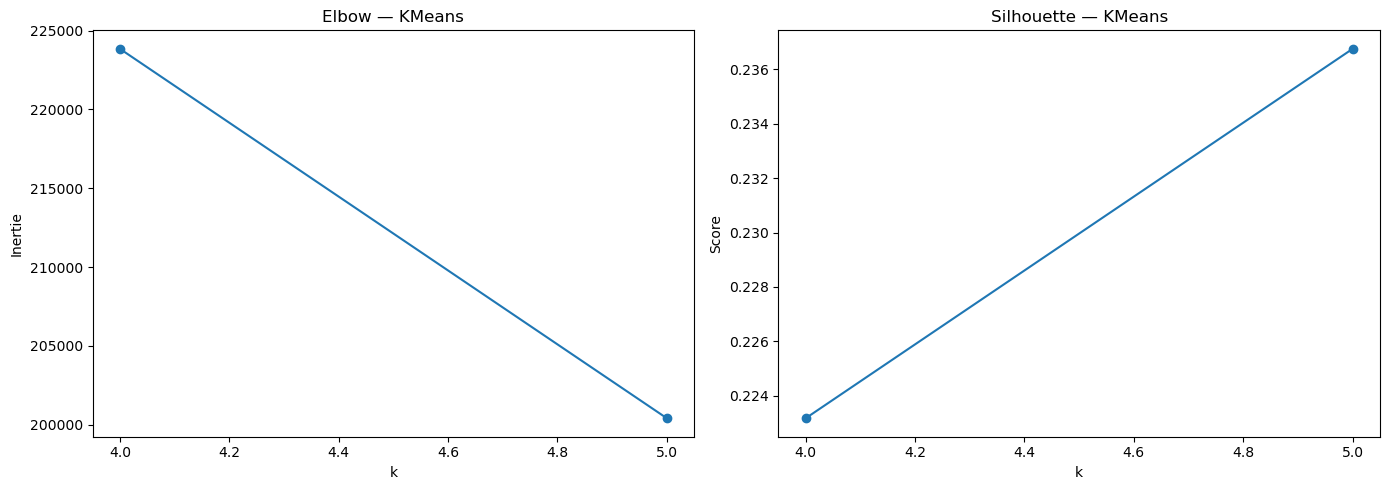

In [8]:
%time

# ============================================================
# SECTION 7 — KMEANS OPTIMISÉ
# ============================================================

# ------------------------------------------------------------
# ÉCHANTILLON POUR MÉTRIQUES
# ------------------------------------------------------------

SAMPLE_SIZE = 50000

idx_sample = np.random.choice(
    len(X_pca),
    SAMPLE_SIZE,
    replace=False
)

X_sample = X_pca[idx_sample]

# ------------------------------------------------------------
# ELBOW + SILHOUETTE
# ------------------------------------------------------------

inertias = []
sil_scores_km = []

for k in range(4, 6):

    print(f"▶ KMeans k={k}")

    km = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=10,
        random_state=RANDOM_STATE
    )

    # Fit sur TOUTES les données
    km.fit(X_pca)

    # Inertie
    inertias.append(km.inertia_)

    # Silhouette seulement sur échantillon
    labels_sample = km.predict(X_sample)

    sil = silhouette_score(
        X_sample,
        labels_sample
    )

    sil_scores_km.append(sil)

    print(f"   Silhouette = {sil:.4f}")

# ------------------------------------------------------------
# PLOTS
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 5)
)

# Elbow
axes[0].plot(
    range(4, 6),
    inertias,
    marker="o"
)

axes[0].set_title("Elbow — KMeans")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertie")

# Silhouette
axes[1].plot(
    range(4, 6),
    sil_scores_km,
    marker="o"
)

axes[1].set_title("Silhouette — KMeans")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Score")

plt.tight_layout()

plt.savefig(
    "figures/02_kmeans_elbow.png",
    dpi=100,
    bbox_inches="tight"
)

plt.show()
plt.close()


KMEANS — k = 4 à 6

▶ KMeans k=4


2026/05/07 17:32:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/07 17:32:53 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


   silhouette      = 0.2252
   davies_bouldin = 1.4294
   calinski_harabasz = 11167.89
   C0: 29,101 | C1: 25,447 | C2: 26,976 | C3: 11,834

▶ KMeans k=5


2026/05/07 17:33:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/07 17:33:59 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


   silhouette      = 0.2371
   davies_bouldin = 1.3979
   calinski_harabasz = 10793.17
   C0: 17,999 | C1: 23,951 | C2: 9,793 | C3: 17,126 | C4: 24,489

▶ KMeans k=6


2026/05/07 17:35:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/07 17:35:02 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


   silhouette      = 0.2302
   davies_bouldin = 1.2999
   calinski_harabasz = 10615.37
   C0: 17,362 | C1: 20,053 | C2: 20,372 | C3: 7,976 | C4: 11,701 | C5: 15,894

RÉSULTATS KMEANS


,model,n_clusters,n_noise,noise_pct,silhouette,davies_bouldin,calinski_harabasz
0,KMeans_k4,4,0,0.0000,0.2252,1.4294,11167.8917
1,KMeans_k5,5,0,0.0000,0.2371,1.3979,10793.1707
2,KMeans_k6,6,0,0.0000,0.2302,1.2999,10615.3662



MEILLEUR MODÈLE
BEST_K = 5
Silhouette = 0.2371

✅ Export réalisé

🎨 Calcul t-SNE...


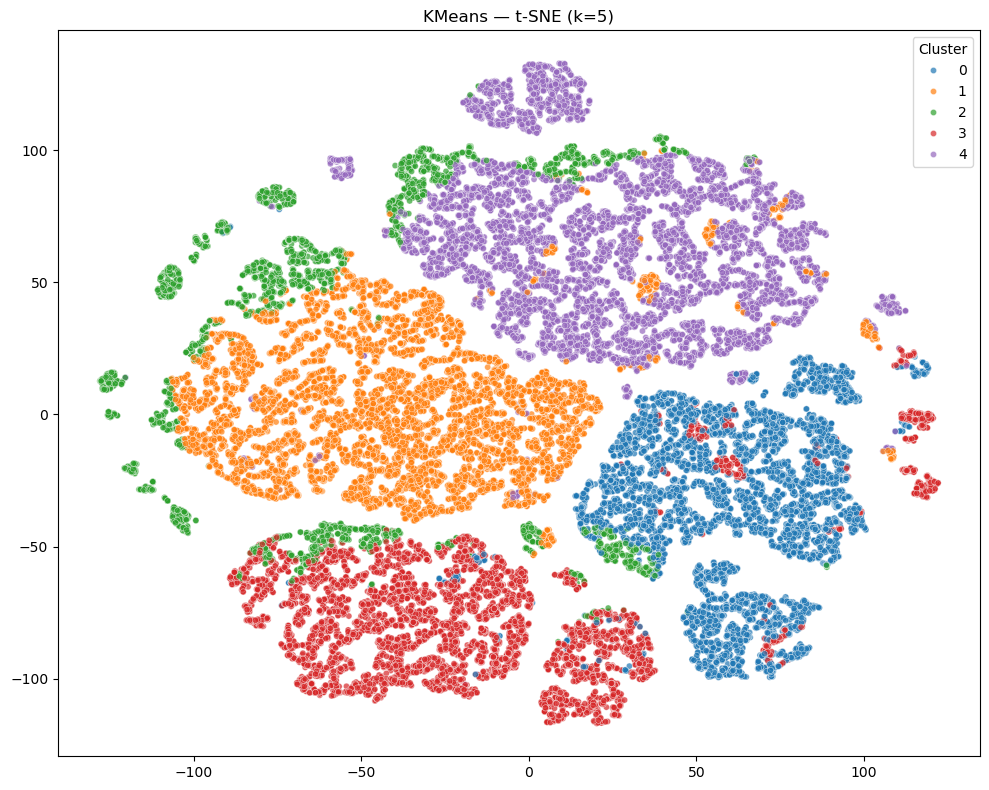


PROFILS CLUSTERS


,Recency,avg_review_score_full,avg_delivery_days,avg_installments,CLV_estimate
cluster_kmeans,,,,,
0,305.7700,2.9100,13.9000,4.7800,106.9700
1,302.8300,5.0000,11.5500,1.0700,54.3700
2,127.5900,4.5700,3.8000,2.1500,44.9000
3,300.4300,2.8900,17.3300,1.1600,57.6000
4,312.4800,4.9800,10.9800,4.8800,128.3000


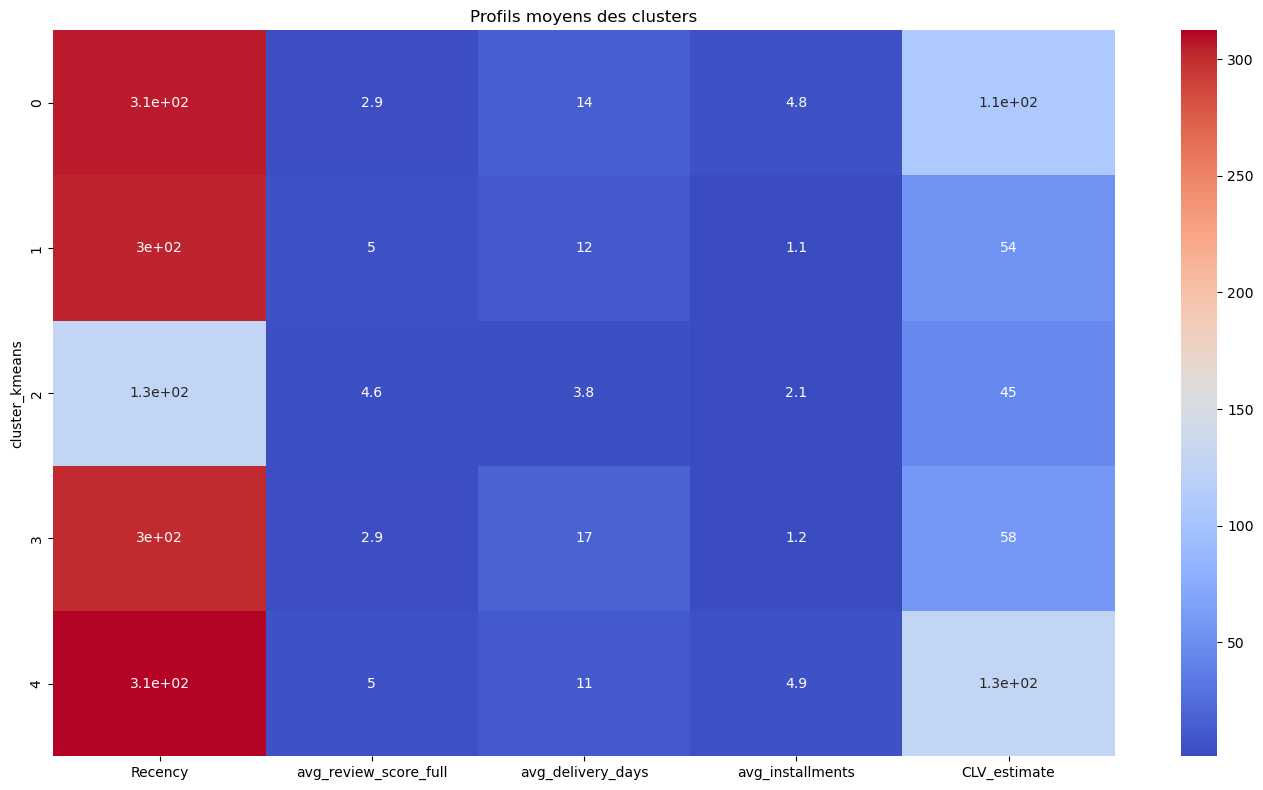


✅ SECTION KMEANS TERMINÉE


In [9]:
# ============================================================
# SECTION 7 — KMEANS OPTIMISÉ + MLFLOW
# ============================================================

# ============================================================
# FONCTION MLFLOW
# ============================================================

def log_mlflow_run(
    run_name,
    params,
    metrics,
    model
):

    with mlflow.start_run(run_name=run_name):

        # ----------------------------------------------------
        # PARAMÈTRES
        # ----------------------------------------------------

        for k, v in params.items():

            mlflow.log_param(k, v)

        # ----------------------------------------------------
        # MÉTRIQUES
        # ----------------------------------------------------

        for k, v in metrics.items():

            if isinstance(v, (int, float)):

                mlflow.log_metric(
                    k,
                    float(v)
                )

        # ----------------------------------------------------
        # MODÈLE
        # ----------------------------------------------------

        mlflow.sklearn.log_model(
            sk_model=model,
            artifact_path="model"
        )

# ============================================================
# KMEANS OPTIMISÉ
# ============================================================

print("\n" + "=" * 60)
print("KMEANS — k = 4 à 6")
print("=" * 60)

# ============================================================
# ÉCHANTILLON POUR MÉTRIQUES
# ============================================================

SAMPLE_SIZE = 50000

idx_sample = np.random.choice(
    len(X_pca),
    SAMPLE_SIZE,
    replace=False
)

X_sample = X_pca[idx_sample]

# ============================================================
# OBJETS STOCKAGE
# ============================================================

KM_MODELS = {}
ALL_RESULTS = []

# ============================================================
# BOUCLE KMEANS
# ============================================================

for k in K_RANGE:

    print(f"\n▶ KMeans k={k}")

    best_sil = -1
    best_km = None
    best_lbs = None

    # --------------------------------------------------------
    # UNE SEULE SEED = largement suffisant
    # --------------------------------------------------------

    for seed in [42]:

        # ----------------------------------------------------
        # MODÈLE
        # ----------------------------------------------------

        km = KMeans(
            n_clusters=k,
            init="k-means++",
            n_init=10,
            max_iter=300,
            random_state=seed
        )

        # ----------------------------------------------------
        # FIT
        # ----------------------------------------------------

        lbs = km.fit_predict(X_pca)

        # ----------------------------------------------------
        # SILHOUETTE SUR ÉCHANTILLON
        # ----------------------------------------------------

        labels_sample = lbs[idx_sample]

        sil = silhouette_score(
            X_sample,
            labels_sample
        )

        # ----------------------------------------------------
        # MEILLEUR MODÈLE
        # ----------------------------------------------------

        if sil > best_sil:

            best_sil = sil
            best_km = km
            best_lbs = lbs.copy()

    # ========================================================
    # MÉTRIQUES
    # ========================================================

    m = evaluate_clustering(
        X_sample,
        labels_sample,
        f"KMeans_k{k}"
    )

    # ========================================================
    # MLFLOW
    # ========================================================

    log_mlflow_run(
        run_name=f"KMeans_k{k}",
        params={
            "algorithm": "KMeans",
            "k": k,
            "n_pca": N_COMP,
            "sample_size": SAMPLE_SIZE
        },
        metrics=m,
        model=best_km
    )

    # ========================================================
    # SAUVEGARDE
    # ========================================================

    joblib.dump(
        best_km,
        f"models/kmeans_k{k}.pkl"
    )

    # ========================================================
    # STOCKAGE
    # ========================================================

    KM_MODELS[k] = {
        "model": best_km,
        "labels": best_lbs.copy(),
        "metrics": m
    }

    ALL_RESULTS.append(m)

    # ========================================================
    # DISTRIBUTION DES CLUSTERS
    # ========================================================

    dist = (
        pd.Series(best_lbs)
        .value_counts()
        .sort_index()
    )

    sizes = " | ".join([
        f"C{c}: {n:,}"
        for c, n in dist.items()
    ])

    # ========================================================
    # AFFICHAGE
    # ========================================================

    print(
        f"   silhouette      = "
        f"{m['silhouette']:.4f}"
    )

    print(
        f"   davies_bouldin = "
        f"{m['davies_bouldin']:.4f}"
    )

    print(
        f"   calinski_harabasz = "
        f"{m['calinski_harabasz']:.2f}"
    )

    print(f"   {sizes}")

# ============================================================
# DATAFRAME RÉSULTATS
# ============================================================

results_kmeans = pd.DataFrame(ALL_RESULTS)

print("\n" + "=" * 60)
print("RÉSULTATS KMEANS")
print("=" * 60)

display(results_kmeans)

# ============================================================
# MEILLEUR MODÈLE
# ============================================================

best_idx = results_kmeans["silhouette"].idxmax()

best_result = results_kmeans.iloc[best_idx]

BEST_K = int(
    best_result["n_clusters"]
)

print("\n" + "=" * 60)
print("MEILLEUR MODÈLE")
print("=" * 60)

print(f"BEST_K = {BEST_K}")

print(
    f"Silhouette = "
    f"{best_result['silhouette']:.4f}"
)

# ============================================================
# MODÈLE FINAL
# ============================================================

FINAL_KMEANS = KM_MODELS[BEST_K]["model"]

FINAL_LABELS = KM_MODELS[BEST_K]["labels"]

# ============================================================
# AJOUT CLUSTERS
# ============================================================

client_df["cluster_kmeans"] = FINAL_LABELS

# ============================================================
# EXPORT
# ============================================================

client_df.to_csv(
    "reports/client_clusters_kmeans.csv",
    index=False
)

print("\n✅ Export réalisé")

# ============================================================
# VISUALISATION TSNE
# ============================================================

print("\n🎨 Calcul t-SNE...")

tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=RANDOM_STATE
)

# échantillon visuel
TSNE_SAMPLE = 40000

idx_vis = np.random.choice(
    len(X_pca),
    TSNE_SAMPLE,
    replace=False
)

X_vis = X_pca[idx_vis]

labels_vis = FINAL_LABELS[idx_vis]

X_tsne = tsne.fit_transform(X_vis)

# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(10, 8))

sns.scatterplot(
    x=X_tsne[:, 0],
    y=X_tsne[:, 1],
    hue=labels_vis,
    palette="tab10",
    s=20,
    alpha=0.7
)

plt.title(
    f"KMeans — t-SNE (k={BEST_K})"
)

plt.legend(
    title="Cluster"
)

plt.tight_layout()

plt.savefig(
    "figures/kmeans_tsne.png",
    dpi=120,
    bbox_inches="tight"
)

plt.show()

plt.close()

# ============================================================
# PROFILS CLUSTERS
# ============================================================

cluster_profile = (
    client_df
    .groupby("cluster_kmeans")[FEATURES_ACTIVE]
    .mean()
    .round(2)
)

print("\n" + "=" * 60)
print("PROFILS CLUSTERS")
print("=" * 60)

display(cluster_profile)

# ============================================================
# HEATMAP
# ============================================================

plt.figure(figsize=(14, 8))

sns.heatmap(
    cluster_profile,
    annot=True,
    cmap="coolwarm"
)

plt.title(
    "Profils moyens des clusters"
)

plt.tight_layout()

plt.savefig(
    "figures/kmeans_cluster_profiles.png",
    dpi=120,
    bbox_inches="tight"
)

plt.show()

plt.close()

print("\n✅ SECTION KMEANS TERMINÉE")


→ k optimal KMeans : 5


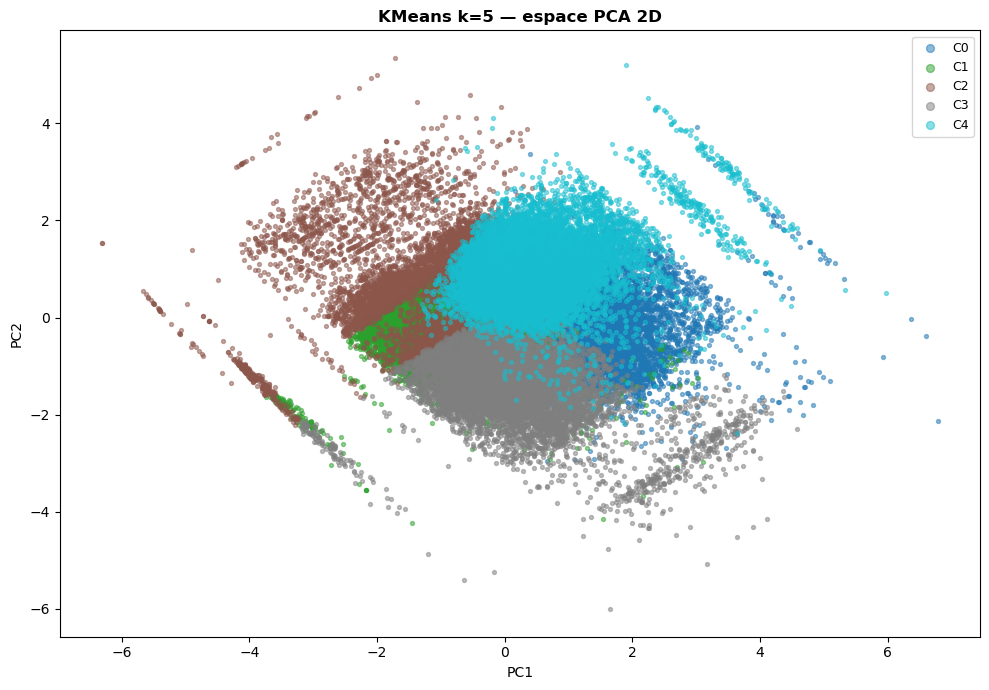

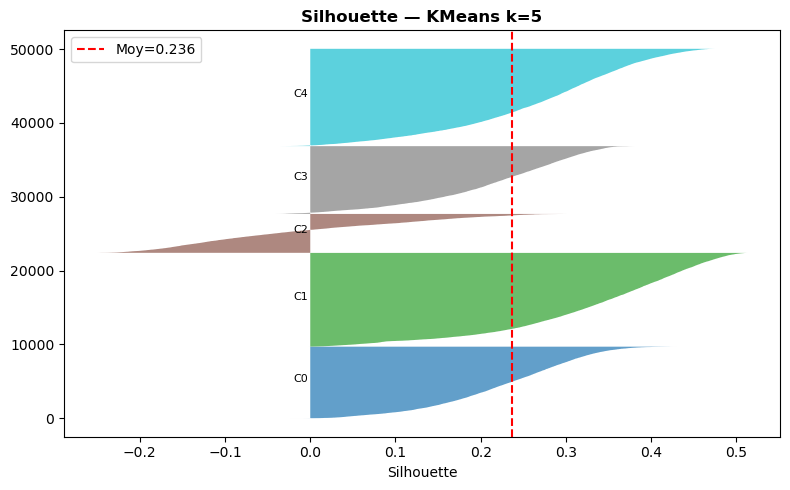


✅ Visualisations terminées


In [10]:
# ============================================================
# MEILLEUR KMEANS
# ============================================================

K_OPT_KM = max(
    KM_MODELS,
    key=lambda k: KM_MODELS[k]["metrics"]["silhouette"]
)

print(f"\n→ k optimal KMeans : {K_OPT_KM}")

# ============================================================
# ÉCHANTILLON VISUALISATION
# ============================================================

VIS_SAMPLE = 50000

idx_vis = np.random.choice(
    len(X_pca),
    VIS_SAMPLE,
    replace=False
)

# ------------------------------------------------------------
# DONNÉES ÉCHANTILLON
# ------------------------------------------------------------

X_vis_pca = X_pca[idx_vis]

X_vis_pca_2d = X_pca_2d[idx_vis]

labels_vis = (
    KM_MODELS[K_OPT_KM]["labels"][idx_vis]
)

# ============================================================
# VISUALISATION CLUSTERS
# ============================================================

plot_clusters_2d(
    X_vis_pca_2d,
    labels_vis,
    f"KMeans k={K_OPT_KM} — espace PCA 2D",
    save=f"figures/03_kmeans_k{K_OPT_KM}.png"
)

# ============================================================
# SILHOUETTE (SUR ÉCHANTILLON)
# ============================================================

plot_silhouette(
    X_vis_pca,
    labels_vis,
    f"Silhouette — KMeans k={K_OPT_KM}",
    save=f"figures/03b_kmeans_sil.png"
)

# ============================================================
# MÉMOIRE
# ============================================================

gc.collect()

print("\n✅ Visualisations terminées")


CAH WARD

🌳 Construction dendrogramme...


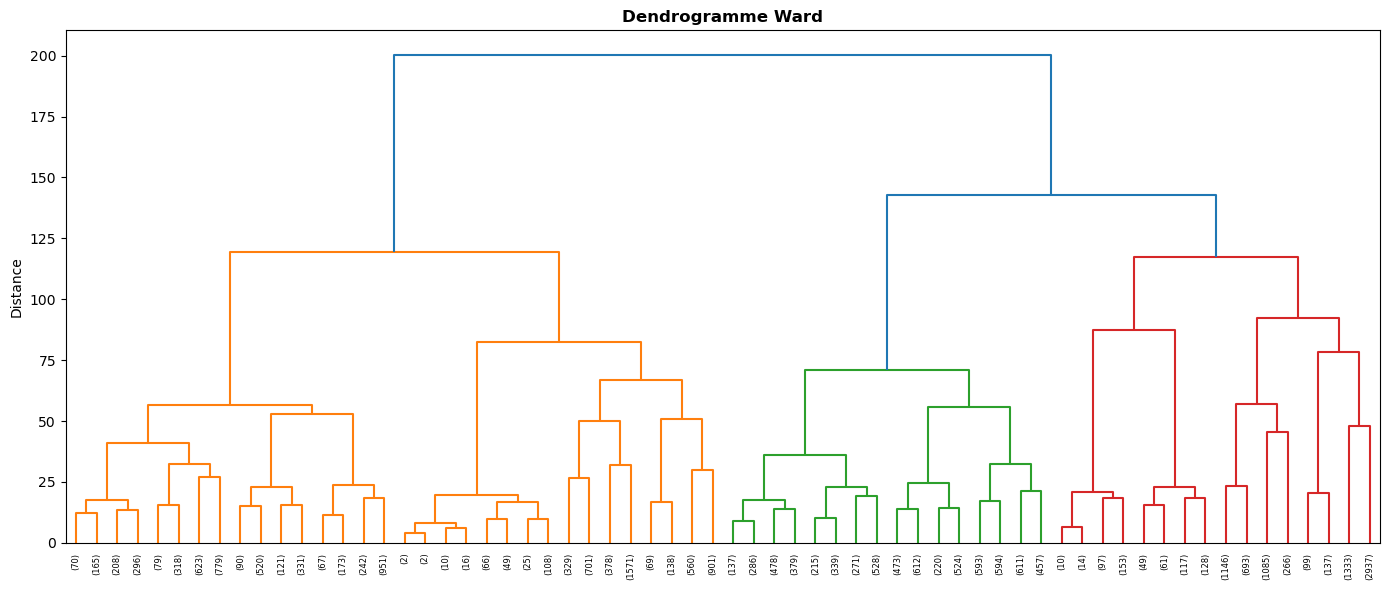


✅ Échantillon CAH : 25,000

CAH Ward — k de 4 à 6 :

▶ CAH k=4


2026/05/07 17:44:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/07 17:44:00 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/07 17:44:00 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!


   silhouette = 0.2208
   davies_bouldin = 1.3985
   C0: 9,847 | C1: 7,813 | C2: 6,650 | C3: 690

▶ CAH k=5


2026/05/07 17:44:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/07 17:44:45 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/07 17:44:45 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!


   silhouette = 0.2416
   davies_bouldin = 1.4308
   C0: 7,813 | C1: 690 | C2: 6,650 | C3: 4,941 | C4: 4,906

▶ CAH k=6


2026/05/07 17:45:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/07 17:45:30 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/07 17:45:30 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!


   silhouette = 0.2527
   davies_bouldin = 1.2820
   C0: 690 | C1: 7,550 | C2: 6,650 | C3: 4,941 | C4: 4,906 | C5: 263

→ k optimal CAH : 6


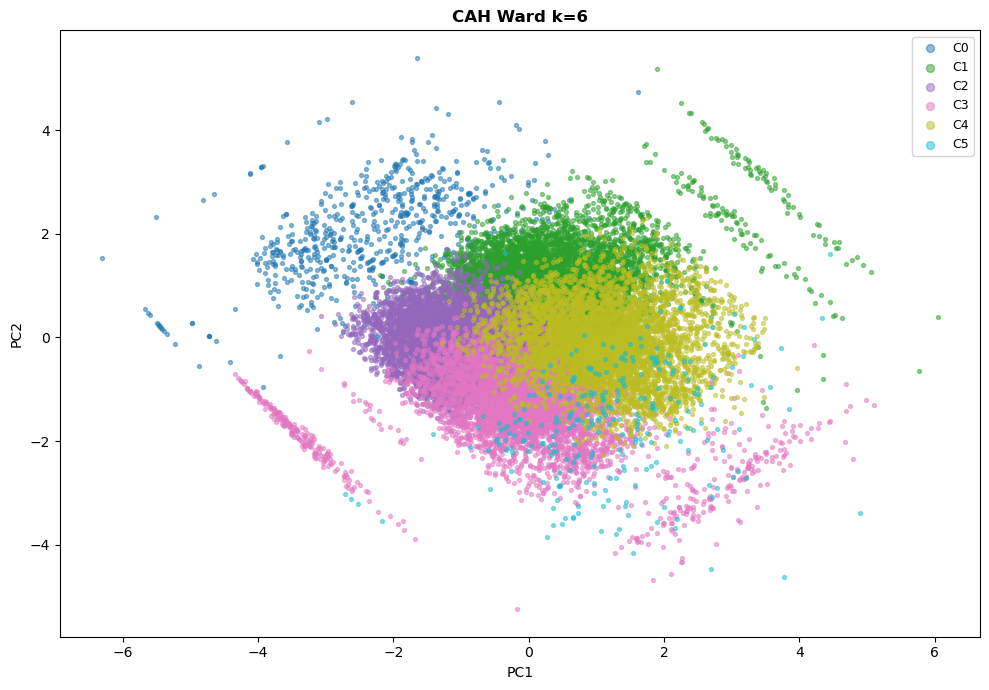


✅ SECTION CAH TERMINÉE


In [11]:
# ============================================================
# SECTION 8 — CAH WARD OPTIMISÉE
# ============================================================

print("\n" + "=" * 60)
print("CAH WARD")
print("=" * 60)

# ============================================================
# ÉCHANTILLON DENDROGRAMME
# ============================================================

rng_cah = np.random.default_rng(
    RANDOM_STATE + 10
)

DENDRO_SAMPLE = 25000

idx_d = rng_cah.choice(
    len(X_pca),
    DENDRO_SAMPLE,
    replace=False
)

print("\n🌳 Construction dendrogramme...")

Z = linkage(
    X_pca[idx_d],
    method="ward"
)

# ============================================================
# DENDROGRAMME
# ============================================================

fig, ax = plt.subplots(
    figsize=(14, 6)
)

dendrogram(
    Z,
    ax=ax,
    truncate_mode="level",
    p=5,
    color_threshold=0.6 * max(Z[:, 2])
)

ax.set_title(
    "Dendrogramme Ward",
    fontweight="bold"
)

ax.set_ylabel("Distance")

plt.tight_layout()

plt.savefig(
    "figures/04_dendrogramme.png",
    dpi=100,
    bbox_inches="tight"
)

plt.show()

plt.close()

del Z

gc.collect()

# ============================================================
# ÉCHANTILLON CAH
# ============================================================

N_CAH = 25000

idx_cah = rng_cah.choice(
    len(X_pca),
    N_CAH,
    replace=False
)

X_cah = X_pca[idx_cah]

print(f"\n✅ Échantillon CAH : {N_CAH:,}")

# ============================================================
# STOCKAGE
# ============================================================

CAH_MODELS = {}

# ============================================================
# BOUCLE CAH
# ============================================================

print("\nCAH Ward — k de 4 à 6 :")

for k in K_RANGE:

    print(f"\n▶ CAH k={k}")

    # --------------------------------------------------------
    # MODÈLE
    # --------------------------------------------------------

    agg = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward"
    )

    # --------------------------------------------------------
    # FIT
    # --------------------------------------------------------

    lbs = agg.fit_predict(X_cah)

    # --------------------------------------------------------
    # MÉTRIQUES
    # --------------------------------------------------------

    m = evaluate_clustering(
        X_cah,
        lbs,
        f"CAH_k{k}"
    )

    # --------------------------------------------------------
    # MLFLOW
    # --------------------------------------------------------

    log_mlflow_run(
        run_name=f"CAH_k{k}",
        params={
            "algorithm": "CAH_WARD",
            "k": k,
            "n_pca": N_COMP,
            "n_sample": N_CAH
        },
        metrics=m,
        model=agg
    )

    # --------------------------------------------------------
    # SAUVEGARDE
    # --------------------------------------------------------

    joblib.dump(
        agg,
        f"models/cah_k{k}.pkl"
    )

    # --------------------------------------------------------
    # STOCKAGE
    # --------------------------------------------------------

    CAH_MODELS[k] = {

        "model": agg,
        "labels": lbs.copy(),
        "idx": idx_cah,
        "metrics": m
    }

    ALL_RESULTS.append(m)

    # --------------------------------------------------------
    # DISTRIBUTION
    # --------------------------------------------------------

    dist = (
        pd.Series(lbs)
        .value_counts()
        .sort_index()
    )

    sizes = " | ".join([
        f"C{c}: {n:,}"
        for c, n in dist.items()
    ])

    # --------------------------------------------------------
    # AFFICHAGE
    # --------------------------------------------------------

    print(
        f"   silhouette = "
        f"{m['silhouette']:.4f}"
    )

    print(
        f"   davies_bouldin = "
        f"{m['davies_bouldin']:.4f}"
    )

    print(f"   {sizes}")

# ============================================================
# MEILLEUR MODÈLE
# ============================================================

K_OPT_CAH = max(
    CAH_MODELS,
    key=lambda k:
        CAH_MODELS[k]["metrics"]["silhouette"]
)

print("\n" + "=" * 60)
print(f"→ k optimal CAH : {K_OPT_CAH}")
print("=" * 60)

# ============================================================
# VISUALISATION
# ============================================================

plot_clusters_2d(

    X_pca_2d[idx_cah],

    CAH_MODELS[K_OPT_CAH]["labels"],

    f"CAH Ward k={K_OPT_CAH}",

    save=f"figures/05_cah_k{K_OPT_CAH}.png"
)

# ============================================================
# LIBÉRATION MÉMOIRE
# ============================================================

del X_cah

gc.collect()

print("\n✅ SECTION CAH TERMINÉE")


GAUSSIAN MIXTURE MODELS

✅ Échantillon GMM : 50,000

GMM — k de 4 à 6 :

▶ GMM k=4


2026/05/07 17:46:07 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/07 17:46:07 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


   silhouette = 0.2144
   BIC = 537,173
   AIC = 536,864
   C0: 13,478 | C1: 14,338 | C2: 18,373 | C3: 3,811

▶ GMM k=5


2026/05/07 17:46:42 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/07 17:46:42 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


   silhouette = 0.2259
   BIC = 535,011
   AIC = 534,623
   C0: 3,872 | C1: 13,790 | C2: 9,909 | C3: 8,644 | C4: 13,785

▶ GMM k=6


2026/05/07 17:47:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/07 17:47:17 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


   silhouette = 0.1975
   BIC = 530,239
   AIC = 529,771
   C0: 8,670 | C1: 7,738 | C2: 4,032 | C3: 10,820 | C4: 9,996 | C5: 8,744


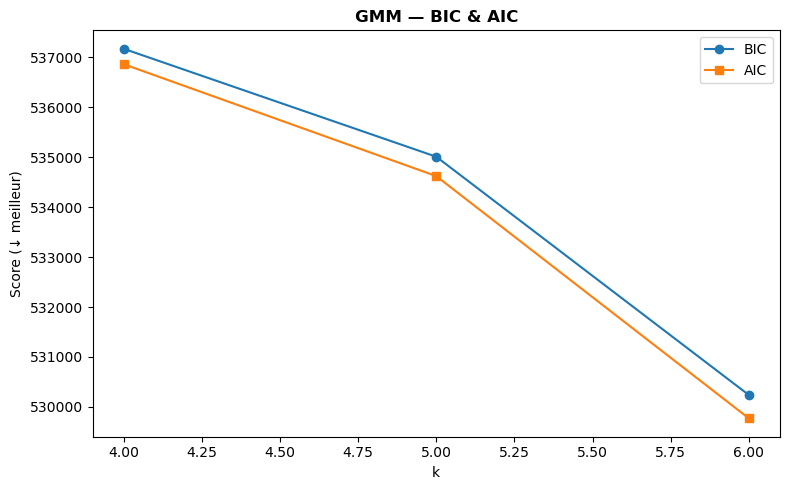


→ k optimal GMM (BIC) : 6


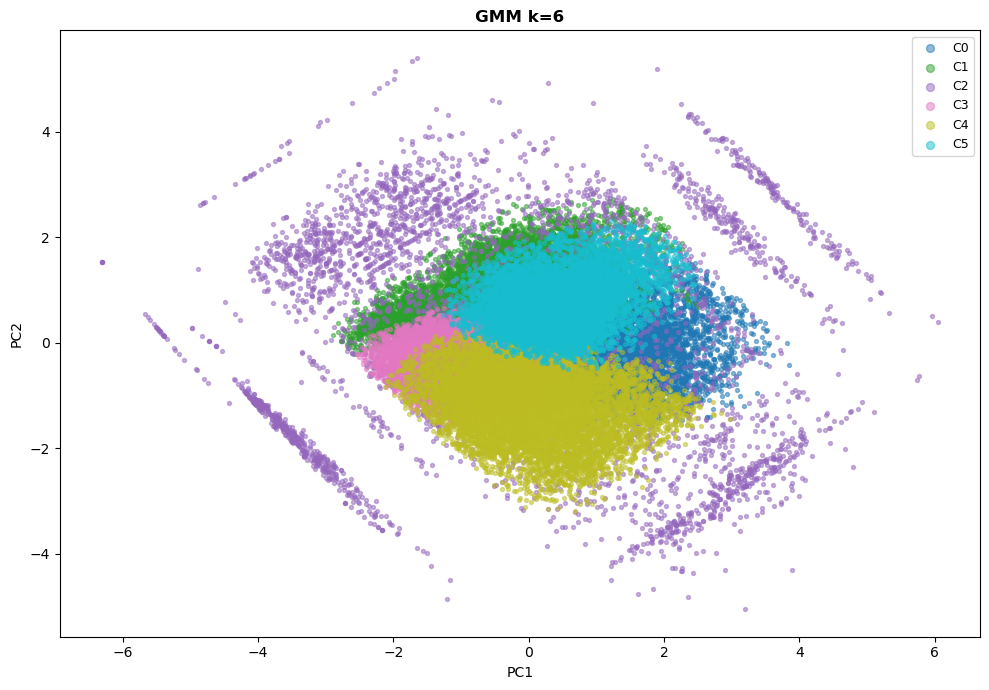


✅ SECTION GMM TERMINÉE


In [12]:
# ============================================================
# SECTION 9 — GMM OPTIMISÉ
# ============================================================

print("\n" + "=" * 60)
print("GAUSSIAN MIXTURE MODELS")
print("=" * 60)

# ============================================================
# ÉCHANTILLON GMM
# ============================================================

N_GMM = 50000

rng_gmm = np.random.default_rng(
    RANDOM_STATE + 20
)

idx_gmm = rng_gmm.choice(
    len(X_pca),
    N_GMM,
    replace=False
)

X_gmm = X_pca[idx_gmm]

print(f"\n✅ Échantillon GMM : {N_GMM:,}")

# ============================================================
# STOCKAGE
# ============================================================

GMM_MODELS = {}

bic_vals = []
aic_vals = []

# ============================================================
# BOUCLE GMM
# ============================================================

print("\nGMM — k de 4 à 6 :")

for k in K_RANGE:

    print(f"\n▶ GMM k={k}")

    # --------------------------------------------------------
    # MODÈLE
    # --------------------------------------------------------

    gmm = GaussianMixture(

        n_components=k,

        covariance_type="diag",

        n_init=2,

        max_iter=200,

        random_state=RANDOM_STATE
    )

    # --------------------------------------------------------
    # FIT
    # --------------------------------------------------------

    gmm.fit(X_gmm)

    # --------------------------------------------------------
    # LABELS
    # --------------------------------------------------------

    lbs = gmm.predict(X_gmm)

    # --------------------------------------------------------
    # MÉTRIQUES
    # --------------------------------------------------------

    m = evaluate_clustering(
        X_gmm,
        lbs,
        f"GMM_k{k}"
    )

    # --------------------------------------------------------
    # BIC / AIC
    # --------------------------------------------------------

    bic = gmm.bic(X_gmm)
    aic = gmm.aic(X_gmm)

    bic_vals.append(bic)
    aic_vals.append(aic)

    # --------------------------------------------------------
    # MLFLOW
    # --------------------------------------------------------

    log_mlflow_run(

        run_name=f"GMM_k{k}",

        params={
            "algorithm": "GMM",
            "k": k,
            "covariance": "diag",
            "n_pca": N_COMP,
            "n_sample": N_GMM
        },

        metrics=m,

        model=gmm
    )

    # --------------------------------------------------------
    # SAUVEGARDE
    # --------------------------------------------------------

    joblib.dump(
        gmm,
        f"models/gmm_k{k}.pkl"
    )

    # --------------------------------------------------------
    # STOCKAGE
    # --------------------------------------------------------

    GMM_MODELS[k] = {

        "model": gmm,
        "labels": lbs.copy(),
        "idx": idx_gmm,
        "metrics": m,
        "bic": bic,
        "aic": aic
    }

    ALL_RESULTS.append(m)

    # --------------------------------------------------------
    # DISTRIBUTION
    # --------------------------------------------------------

    dist = (
        pd.Series(lbs)
        .value_counts()
        .sort_index()
    )

    sizes = " | ".join([
        f"C{c}: {n:,}"
        for c, n in dist.items()
    ])

    # --------------------------------------------------------
    # AFFICHAGE
    # --------------------------------------------------------

    print(
        f"   silhouette = "
        f"{m['silhouette']:.4f}"
    )

    print(
        f"   BIC = "
        f"{bic:,.0f}"
    )

    print(
        f"   AIC = "
        f"{aic:,.0f}"
    )

    print(f"   {sizes}")

# ============================================================
# PLOT BIC / AIC
# ============================================================

fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.plot(
    list(K_RANGE),
    bic_vals,
    marker="o",
    label="BIC"
)

ax.plot(
    list(K_RANGE),
    aic_vals,
    marker="s",
    label="AIC"
)

ax.set_xlabel("k")

ax.set_ylabel(
    "Score (↓ meilleur)"
)

ax.set_title(
    "GMM — BIC & AIC",
    fontweight="bold"
)

ax.legend()

plt.tight_layout()

plt.savefig(
    "figures/06_gmm_bic_aic.png",
    dpi=100,
    bbox_inches="tight"
)

plt.show()

plt.close()

# ============================================================
# MEILLEUR MODÈLE
# ============================================================

K_OPT_GMM = min(
    GMM_MODELS,
    key=lambda k:
        GMM_MODELS[k]["bic"]
)

print("\n" + "=" * 60)
print(f"→ k optimal GMM (BIC) : {K_OPT_GMM}")
print("=" * 60)

# ============================================================
# VISUALISATION
# ============================================================

plot_clusters_2d(

    X_pca_2d[idx_gmm],

    GMM_MODELS[K_OPT_GMM]["labels"],

    f"GMM k={K_OPT_GMM}",

    save=f"figures/06b_gmm_k{K_OPT_GMM}.png"
)

# ============================================================
# LIBÉRATION MÉMOIRE
# ============================================================

del X_gmm

gc.collect()

print("\n✅ SECTION GMM TERMINÉE")


DBSCAN

✅ Échantillon DBSCAN : 49,995

📏 Calcul epsilon optimal...


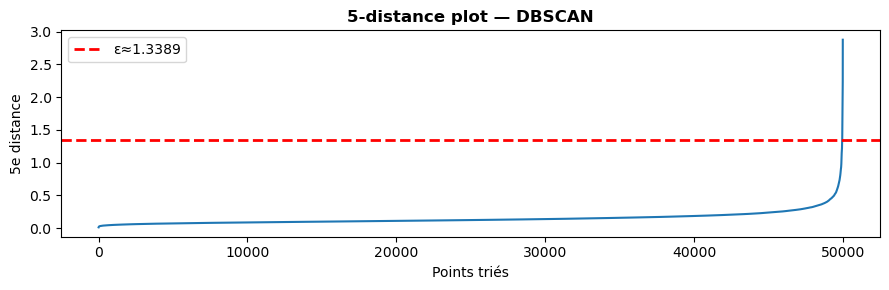


✅ ε optimal : 1.3389

🔍 Combinaisons testées : 9

▶ DBSCAN eps=0.9372 min_samples=5

▶ DBSCAN eps=0.9372 min_samples=10

▶ DBSCAN eps=0.9372 min_samples=15

▶ DBSCAN eps=1.3389 min_samples=5

▶ DBSCAN eps=1.3389 min_samples=10

▶ DBSCAN eps=1.3389 min_samples=15


2026/05/07 19:56:36 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/07 19:56:36 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/07 19:56:36 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!


   silhouette = 0.3943
   clusters = 6
   bruit = 86

▶ DBSCAN eps=1.7405 min_samples=5

▶ DBSCAN eps=1.7405 min_samples=10


2026/05/07 20:03:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/07 20:03:30 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/07 20:03:30 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!


   silhouette = 0.4223
   clusters = 4
   bruit = 16

▶ DBSCAN eps=1.7405 min_samples=15

→ Meilleur DBSCAN : eps=1.7405 ms=10 k=4 sil=0.4223


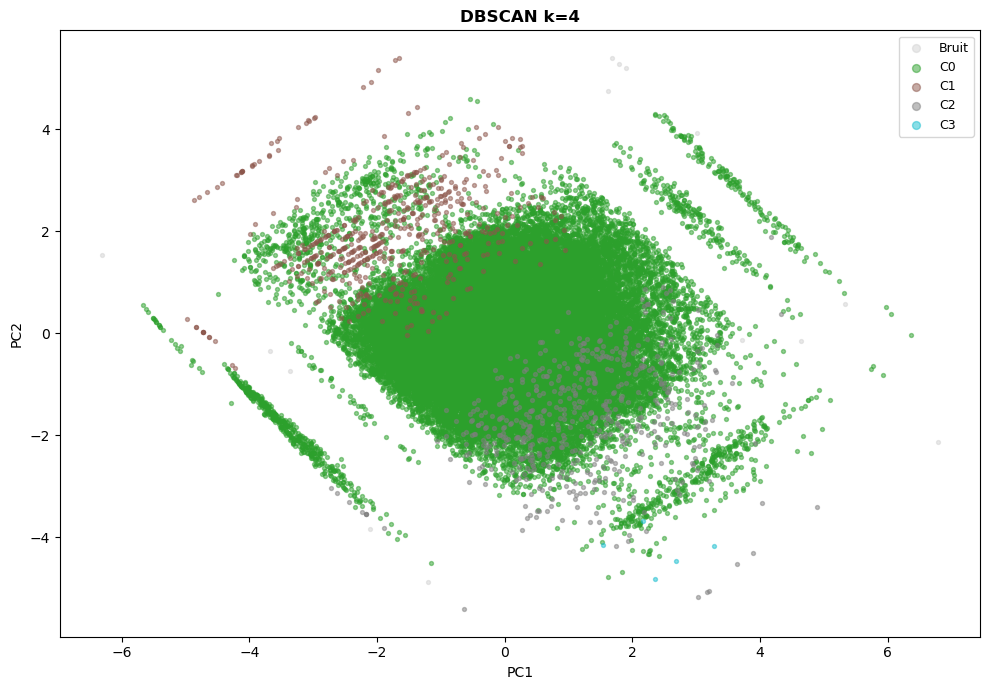


✅ SECTION DBSCAN TERMINÉE


In [13]:
# ============================================================
# SECTION 10 — DBSCAN OPTIMISÉ
# ============================================================

print("\n" + "=" * 60)
print("DBSCAN")
print("=" * 60)

rng_dbs = np.random.default_rng(
    RANDOM_STATE + 20
)

# ============================================================
# ÉCHANTILLON DBSCAN
# ============================================================

N_DBSCAN_OPT = 50000

# ------------------------------------------------------------
# STRATIFICATION
# ------------------------------------------------------------

strate = (

    pd.qcut(
        client_df["Recency"].clip(
            upper=client_df["Recency"].quantile(0.99)
        ),
        q=3,
        labels=False
    ).astype(str)

    + "_"

    +

    pd.qcut(
        client_df["Monetary"].clip(
            upper=client_df["Monetary"].quantile(0.99)
        ),
        q=3,
        labels=False,
        duplicates="drop"
    ).astype(str)

)

n_par_strate = max(
    1,
    N_DBSCAN_OPT // strate.nunique()
)

idx_parts = []

for s, grp in strate.groupby(strate):

    idx_parts.extend(

        np.random.choice(
            grp.index.tolist(),
            min(n_par_strate, len(grp)),
            replace=False
        )

    )

idx_dbs = np.array(
    idx_parts[:N_DBSCAN_OPT]
)

X_dbs = X_pca[idx_dbs]

print(
    f"\n✅ Échantillon DBSCAN : "
    f"{len(X_dbs):,}"
)

# ============================================================
# K-DISTANCE
# ============================================================

print("\n📏 Calcul epsilon optimal...")

from kneed import KneeLocator

nbrs = NearestNeighbors(
    n_neighbors=5,
    n_jobs=-1
).fit(X_dbs)

dist5, _ = nbrs.kneighbors(X_dbs)

d_sorted = np.sort(
    dist5[:, 4]
)

kl = KneeLocator(
    range(len(d_sorted)),
    d_sorted,
    curve="convex",
    direction="increasing"
)

EPS = (

    float(d_sorted[kl.knee])

    if kl.knee

    else float(
        np.percentile(d_sorted, 85)
    )
)

del nbrs
del dist5

gc.collect()

# ============================================================
# PLOT K-DISTANCE
# ============================================================

plt.figure(figsize=(9, 3))

plt.plot(
    d_sorted,
    lw=1.5
)

plt.axhline(
    EPS,
    color="red",
    ls="--",
    lw=2,
    label=f"ε≈{EPS:.4f}"
)

plt.title(
    "5-distance plot — DBSCAN",
    fontweight="bold"
)

plt.xlabel("Points triés")

plt.ylabel("5e distance")

plt.legend()

plt.tight_layout()

plt.savefig(
    "figures/07_dbscan_eps.png",
    dpi=100,
    bbox_inches="tight"
)

plt.show()

plt.close()

print(f"\n✅ ε optimal : {EPS:.4f}")

# ============================================================
# GRID SEARCH RÉDUIT
# ============================================================

MAX_NOISE = int(
    len(X_dbs) * 0.15
)

grid_dbs = [

    (round(EPS * r, 4), ms)

    for r in [0.7, 1.0, 1.3]

    for ms in [5, 10, 15]

]

print(
    f"\n🔍 Combinaisons testées : "
    f"{len(grid_dbs)}"
)

# ============================================================
# MEILLEUR MODÈLE
# ============================================================

best_dbs = {
    "sil": -1,
    "labels": None
}

# ============================================================
# BOUCLE DBSCAN
# ============================================================

for eps, ms in grid_dbs:

    print(
        f"\n▶ DBSCAN "
        f"eps={eps} "
        f"min_samples={ms}"
    )

    # --------------------------------------------------------
    # MODÈLE
    # --------------------------------------------------------

    dbs = DBSCAN(
        eps=eps,
        min_samples=ms,
        n_jobs=-1
    )

    # --------------------------------------------------------
    # FIT
    # --------------------------------------------------------

    lbs = dbs.fit_predict(X_dbs)

    # --------------------------------------------------------
    # MÉTRIQUES
    # --------------------------------------------------------

    m = evaluate_clustering(
        X_dbs,
        lbs,
        f"DBSCAN_e{eps}_ms{ms}"
    )

    if m is None:

        print("   ⚠ clustering invalide")

        continue

    nc = m["n_clusters"]
    nn = m["n_noise"]

    # --------------------------------------------------------
    # FILTRAGE
    # --------------------------------------------------------

    if (

        K_MIN <= nc <= K_MAX

        and

        nn <= MAX_NOISE

    ):

        # ----------------------------------------------------
        # MLFLOW
        # ----------------------------------------------------

        log_mlflow_run(

            run_name=f"DBSCAN_e{eps}_ms{ms}",

            params={

                "algorithm": "DBSCAN",

                "eps": eps,

                "min_samples": ms,

                "n_sample": N_DBSCAN_OPT
            },

            metrics=m,

            model=dbs
        )

        ALL_RESULTS.append(m)

        # ----------------------------------------------------
        # BEST MODEL
        # ----------------------------------------------------

        if m["silhouette"] > best_dbs["sil"]:

            best_dbs = {

                "sil": m["silhouette"],

                "labels": lbs.copy(),

                "nc": nc,

                "eps": eps,

                "ms": ms
            }

        # ----------------------------------------------------
        # AFFICHAGE
        # ----------------------------------------------------

        print(
            f"   silhouette = "
            f"{m['silhouette']:.4f}"
        )

        print(
            f"   clusters = {nc}"
        )

        print(
            f"   bruit = {nn}"
        )

    del lbs

    gc.collect()

# ============================================================
# MEILLEUR DBSCAN
# ============================================================

if best_dbs["labels"] is not None:

    print("\n" + "=" * 60)

    print(
        f"→ Meilleur DBSCAN : "
        f"eps={best_dbs['eps']} "
        f"ms={best_dbs['ms']} "
        f"k={best_dbs['nc']} "
        f"sil={best_dbs['sil']:.4f}"
    )

    print("=" * 60)

    # --------------------------------------------------------
    # VISUALISATION
    # --------------------------------------------------------

    plot_clusters_2d(

        X_pca_2d[idx_dbs],

        best_dbs["labels"],

        f"DBSCAN k={best_dbs['nc']}",

        save="figures/08_dbscan_best.png"
    )

    # --------------------------------------------------------
    # SAUVEGARDE
    # --------------------------------------------------------

    best_dbscan_model = DBSCAN(

        eps=best_dbs["eps"],

        min_samples=best_dbs["ms"]
    )

    best_dbscan_model.fit(X_dbs)

    joblib.dump(

        best_dbscan_model,

        "models/dbscan_best.pkl"
    )

else:

    print(
        "\n⚠️ Aucun DBSCAN valide"
    )

# ============================================================
# LIBÉRATION MÉMOIRE
# ============================================================

del X_dbs

gc.collect()

print("\n✅ SECTION DBSCAN TERMINÉE")

In [14]:
# ============================================================
# SECTION 11 — HDBSCAN OPTIMISÉ
# ============================================================

print("\n" + "=" * 60)
print("HDBSCAN")
print("=" * 60)

# ============================================================
# ÉCHANTILLON HDBSCAN
# ============================================================

rng_hdb = np.random.default_rng(
    RANDOM_STATE + 30
)

N_HDBSCAN = 50000

idx_hdb = rng_hdb.choice(
    len(X_pca),
    N_HDBSCAN,
    replace=False
)

X_hdb = X_pca[idx_hdb]

print(
    f"\n✅ Échantillon HDBSCAN : "
    f"{len(X_hdb):,}"
)

# ============================================================
# GRILLE RÉDUITE
# ============================================================

grid_hdb = [

    (mc, ms)

    for mc in [20, 50, 80]

    for ms in [5, 10]

]

print(
    f"\n🔍 Configurations testées : "
    f"{len(grid_hdb)}"
)

# ============================================================
# MEILLEUR MODÈLE
# ============================================================

best_hdb = {
    "sil": -1,
    "labels": None
}

# ============================================================
# BOUCLE HDBSCAN
# ============================================================

for mc, ms in grid_hdb:

    print(
        f"\n▶ HDBSCAN "
        f"mc={mc} "
        f"ms={ms}"
    )

    # --------------------------------------------------------
    # MODÈLE
    # --------------------------------------------------------

    clf = hdbscan.HDBSCAN(

        min_cluster_size=mc,

        min_samples=ms,

        metric="euclidean",

        cluster_selection_method="eom",

        core_dist_n_jobs=-1
    )

    # --------------------------------------------------------
    # FIT
    # --------------------------------------------------------

    lbs = clf.fit_predict(X_hdb)

    # --------------------------------------------------------
    # MÉTRIQUES
    # --------------------------------------------------------

    m = evaluate_clustering(

        X_hdb,

        lbs,

        f"HDBSCAN_mc{mc}_ms{ms}"
    )

    if m is None:

        print("   ⚠ clustering invalide")

        continue

    nc = m["n_clusters"]

    noise_pct = m["noise_pct"]

    # --------------------------------------------------------
    # FILTRAGE
    # --------------------------------------------------------

    if (

        K_MIN <= nc <= K_MAX

        and

        noise_pct <= 20

    ):

        # ----------------------------------------------------
        # MLFLOW
        # ----------------------------------------------------

        log_mlflow_run(

            run_name=f"HDBSCAN_mc{mc}_ms{ms}",

            params={

                "algorithm": "HDBSCAN",

                "min_cluster_size": mc,

                "min_samples": ms,

                "n_sample": N_HDBSCAN
            },

            metrics=m,

            model=clf
        )

        ALL_RESULTS.append(m)

        # ----------------------------------------------------
        # BEST MODEL
        # ----------------------------------------------------

        if m["silhouette"] > best_hdb["sil"]:

            best_hdb = {

                "sil": m["silhouette"],

                "labels": lbs.copy(),

                "nc": nc,

                "mc": mc,

                "ms": ms
            }

        # ----------------------------------------------------
        # AFFICHAGE
        # ----------------------------------------------------

        print(
            f"   silhouette = "
            f"{m['silhouette']:.4f}"
        )

        print(
            f"   clusters = {nc}"
        )

        print(
            f"   bruit = "
            f"{noise_pct:.2f}%"
        )

    del lbs

    gc.collect()

# ============================================================
# MEILLEUR HDBSCAN
# ============================================================

if best_hdb["labels"] is not None:

    print("\n" + "=" * 60)

    print(
        f"→ Meilleur HDBSCAN : "
        f"mc={best_hdb['mc']} "
        f"ms={best_hdb['ms']} "
        f"k={best_hdb['nc']} "
        f"sil={best_hdb['sil']:.4f}"
    )

    print("=" * 60)

    # --------------------------------------------------------
    # VISUALISATION
    # --------------------------------------------------------

    plot_clusters_2d(

        X_pca_2d[idx_hdb],

        best_hdb["labels"],

        f"HDBSCAN k={best_hdb['nc']}",

        save="figures/09_hdbscan_best.png"
    )

    # --------------------------------------------------------
    # SAUVEGARDE
    # --------------------------------------------------------

    best_hdbscan_model = hdbscan.HDBSCAN(

        min_cluster_size=best_hdb["mc"],

        min_samples=best_hdb["ms"]
    )

    best_hdbscan_model.fit(X_hdb)

    joblib.dump(

        best_hdbscan_model,

        "models/hdbscan_best.pkl"
    )

else:

    print(
        "\n⚠️ Aucun HDBSCAN valide"
    )

# ============================================================
# LIBÉRATION MÉMOIRE
# ============================================================

del X_hdb

gc.collect()

print("\n✅ SECTION HDBSCAN TERMINÉE")


HDBSCAN

✅ Échantillon HDBSCAN : 50,000

🔍 Configurations testées : 6

▶ HDBSCAN mc=20 ms=5

▶ HDBSCAN mc=20 ms=10

▶ HDBSCAN mc=50 ms=5

▶ HDBSCAN mc=50 ms=10

▶ HDBSCAN mc=80 ms=5

▶ HDBSCAN mc=80 ms=10

⚠️ Aucun HDBSCAN valide

✅ SECTION HDBSCAN TERMINÉE



COMPARAISON DES MODÈLES

🏆 TOP 15 MODÈLES



,model,n_clusters,noise_pct,silhouette,davies_bouldin,calinski_harabasz
10,DBSCAN_e1.7405_ms10,4,0.0320,0.4223,0.7459,1817.4223
9,DBSCAN_e1.3389_ms15,6,0.1720,0.3943,0.7442,1833.5664
5,CAH_k6,6,0.0000,0.2527,1.2820,4852.6972
4,CAH_k5,5,0.0000,0.2416,1.4308,5050.5295
1,KMeans_k5,5,0.0000,0.2371,1.3979,10793.1707
2,KMeans_k6,6,0.0000,0.2302,1.2999,10615.3662
7,GMM_k5,5,0.0000,0.2259,3.8213,6729.9404
0,KMeans_k4,4,0.0000,0.2252,1.4294,11167.8917
3,CAH_k4,4,0.0000,0.2208,1.3985,4993.0204
6,GMM_k4,4,0.0000,0.2144,4.3275,6878.7547



🏆 Meilleur modèle : DBSCAN_e1.7405_ms10


,model,n_clusters,silhouette,davies_bouldin,noise_pct,score
10,DBSCAN_e1.7405_ms10,4,0.4223,0.7459,0.0320,0.6222
5,CAH_k6,6,0.2527,1.2820,0.0000,0.5375
2,KMeans_k6,6,0.2302,1.2999,0.0000,0.5250
1,KMeans_k5,5,0.2371,1.3979,0.0000,0.5216
4,CAH_k5,5,0.2416,1.4308,0.0000,0.5216
0,KMeans_k4,4,0.2252,1.4294,0.0000,0.5135
3,CAH_k4,4,0.2208,1.3985,0.0000,0.5134
9,DBSCAN_e1.3389_ms15,6,0.3943,0.7442,0.1720,0.4455
7,GMM_k5,5,0.2259,3.8213,0.0000,0.3481
8,GMM_k6,6,0.1975,3.6652,0.0000,0.3447


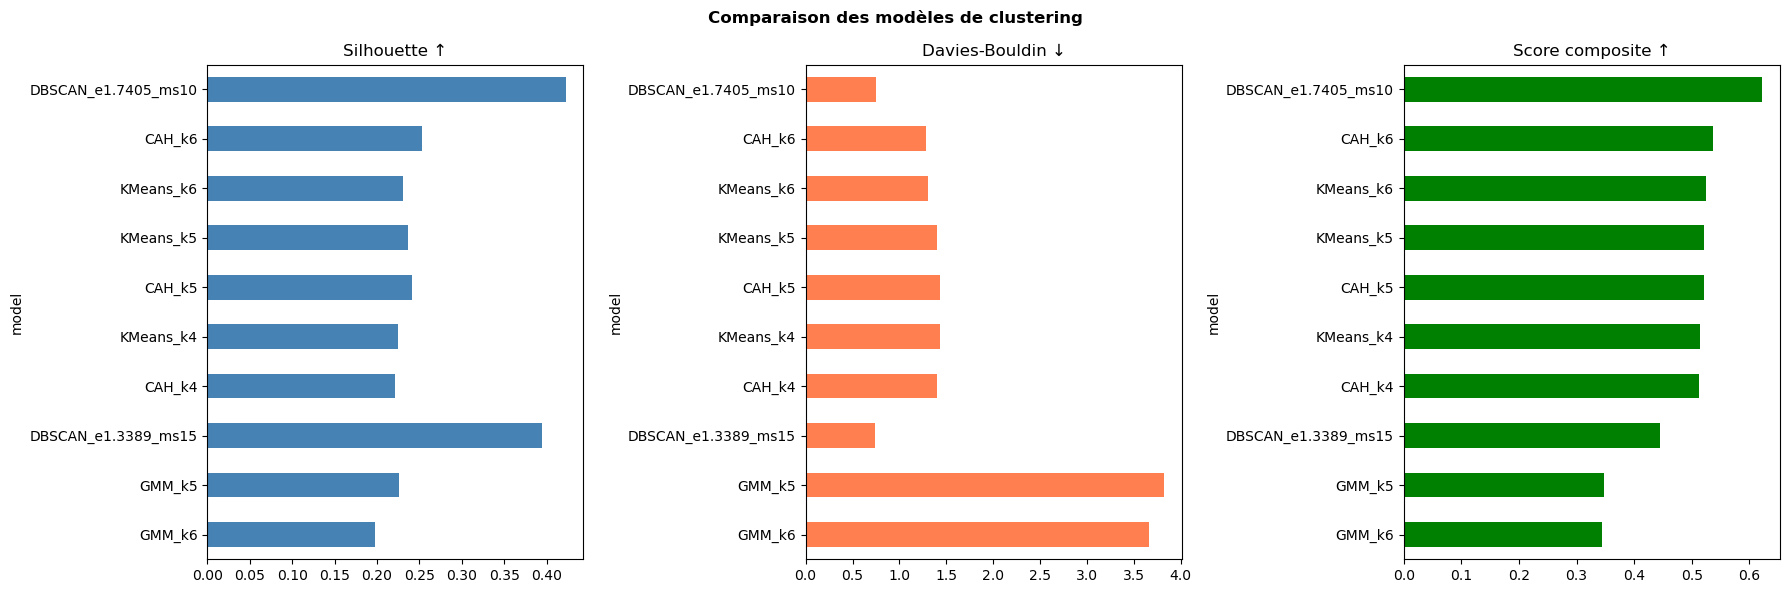


✅ Tableau exporté

SÉLECTION DU MODÈLE FINAL

✅ Modèle final sauvegardé
📁 models/model_final.pkl
📌 Nombre de clusters : 5

✅ Segmentation exportée

✅ SECTION COMPARAISON TERMINÉE


In [15]:
# ============================================================
# SECTION 12 — COMPARAISON MULTI-CRITÈRES
# ============================================================

print("\n" + "=" * 80)
print("COMPARAISON DES MODÈLES")
print("=" * 80)

# ============================================================
# DATAFRAME RÉSULTATS
# ============================================================

df_results = pd.DataFrame([

    r for r in ALL_RESULTS

    if r is not None

])

# ------------------------------------------------------------
# TRI
# ------------------------------------------------------------

df_results = df_results.sort_values(
    "silhouette",
    ascending=False
)

# ============================================================
# TABLEAU PRINCIPAL
# ============================================================

cols_show = [

    "model",

    "n_clusters",

    "noise_pct",

    "silhouette",

    "davies_bouldin",

    "calinski_harabasz"
]

print("\n🏆 TOP 15 MODÈLES\n")

display(

    df_results[cols_show]
    .head(15)
    .round(4)

)

# ============================================================
# SCORE COMPOSITE
# ============================================================

df_r = df_results.copy()

# ------------------------------------------------------------
# NORMALISATION
# ------------------------------------------------------------

df_r["db_norm"] = (

    1

    -

    df_r["davies_bouldin"]

    /

    (

        df_r["davies_bouldin"].max()

        + 1e-9
    )
)

df_r["noise_norm"] = (

    1

    -

    df_r["noise_pct"]

    /

    (

        df_r["noise_pct"].max()

        + 1e-9
    )
)

# ------------------------------------------------------------
# SCORE GLOBAL
# ------------------------------------------------------------

df_r["score"] = (

    0.50 * df_r["silhouette"]

    +

    0.30 * df_r["db_norm"]

    +

    0.20 * df_r["noise_norm"]

)

# ------------------------------------------------------------
# TRI FINAL
# ------------------------------------------------------------

df_r = df_r.sort_values(
    "score",
    ascending=False
)

# ============================================================
# MEILLEUR MODÈLE
# ============================================================

BEST_MODEL_NAME = df_r.iloc[0]["model"]

print("\n" + "=" * 80)

print(
    f"🏆 Meilleur modèle : "
    f"{BEST_MODEL_NAME}"
)

print("=" * 80)

display(

    df_r[[
        "model",
        "n_clusters",
        "silhouette",
        "davies_bouldin",
        "noise_pct",
        "score"
    ]]
    .head(10)
    .round(4)

)

# ============================================================
# VISUALISATION COMPARATIVE
# ============================================================

TOP_N = 10

df_plot = (

    df_r
    .head(TOP_N)
    .set_index("model")

)

# ------------------------------------------------------------
# FIGURE
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 6)
)

# ------------------------------------------------------------
# SILHOUETTE
# ------------------------------------------------------------

df_plot["silhouette"].plot(

    kind="barh",

    ax=axes[0],

    color="steelblue"
)

axes[0].set_title(
    "Silhouette ↑"
)

axes[0].invert_yaxis()

# ------------------------------------------------------------
# DAVIES-BOULDIN
# ------------------------------------------------------------

df_plot["davies_bouldin"].plot(

    kind="barh",

    ax=axes[1],

    color="coral"
)

axes[1].set_title(
    "Davies-Bouldin ↓"
)

axes[1].invert_yaxis()

# ------------------------------------------------------------
# SCORE COMPOSITE
# ------------------------------------------------------------

df_plot["score"].plot(

    kind="barh",

    ax=axes[2],

    color="green"
)

axes[2].set_title(
    "Score composite ↑"
)

axes[2].invert_yaxis()

# ------------------------------------------------------------
# GLOBAL
# ------------------------------------------------------------

plt.suptitle(

    "Comparaison des modèles de clustering",

    fontweight="bold"
)

plt.tight_layout()

plt.savefig(

    "figures/10_comparaison.png",

    dpi=100,

    bbox_inches="tight"
)

plt.show()

plt.close()

# ============================================================
# EXPORT
# ============================================================

df_r.to_csv(

    "reports/comparaison_modeles.csv",

    index=False
)

print("\n✅ Tableau exporté")

# ============================================================
# CHOIX DU MODÈLE FINAL
# ============================================================

print("\n" + "=" * 80)
print("SÉLECTION DU MODÈLE FINAL")
print("=" * 80)

# ------------------------------------------------------------
# KMEANS
# ------------------------------------------------------------

if "KMeans" in BEST_MODEL_NAME:

    k_str = int(
        BEST_MODEL_NAME.split("_k")[1]
    )

    model_final = KM_MODELS[k_str]["model"]

    labels_final = KM_MODELS[k_str]["labels"]

    K_FINAL = k_str

# ------------------------------------------------------------
# CAH
# ------------------------------------------------------------

elif "CAH" in BEST_MODEL_NAME:

    k_str = int(
        BEST_MODEL_NAME.split("_k")[1]
    )

    model_final = CAH_MODELS[k_str]["model"]

    labels_final = CAH_MODELS[k_str]["labels"]

    K_FINAL = k_str

# ------------------------------------------------------------
# GMM
# ------------------------------------------------------------

elif "GMM" in BEST_MODEL_NAME:

    k_str = int(
        BEST_MODEL_NAME.split("_k")[1]
    )

    model_final = GMM_MODELS[k_str]["model"]

    labels_final = GMM_MODELS[k_str]["labels"]

    K_FINAL = k_str

# ------------------------------------------------------------
# FALLBACK
# ------------------------------------------------------------

else:

    K_FINAL = K_OPT_KM

    model_final = KM_MODELS[K_FINAL]["model"]

    labels_final = KM_MODELS[K_FINAL]["labels"]

# ============================================================
# SAUVEGARDE MODÈLE FINAL
# ============================================================

joblib.dump(

    model_final,

    "models/model_final.pkl"
)

print(
    f"\n✅ Modèle final sauvegardé"
)

print(
    f"📁 models/model_final.pkl"
)

print(
    f"📌 Nombre de clusters : {K_FINAL}"
)

# ============================================================
# AJOUT LABELS
# ============================================================

client_df["cluster_final"] = labels_final

# ============================================================
# EXPORT FINAL
# ============================================================

client_df.to_csv(

    "reports/client_segmentation_final.csv",

    index=False
)

print(
    "\n✅ Segmentation exportée"
)

# ============================================================
# LIBÉRATION MÉMOIRE
# ============================================================

gc.collect()

print("\n✅ SECTION COMPARAISON TERMINÉE")


PROFILING DES CLUSTERS

📊 PROFILS MÉDIANS



,Recency,avg_review_score_full,avg_delivery_days,avg_installments,CLV_estimate
cluster,,,,,
0,287.0000,3.0000,12.0000,4.0000,71.9330
1,283.0000,5.0000,10.0000,1.0000,37.6700
2,93.0000,5.0000,4.0000,1.0000,31.8170
3,276.0000,3.0000,13.0000,1.0000,39.2930
4,305.0000,5.0000,10.0000,4.0000,73.8450


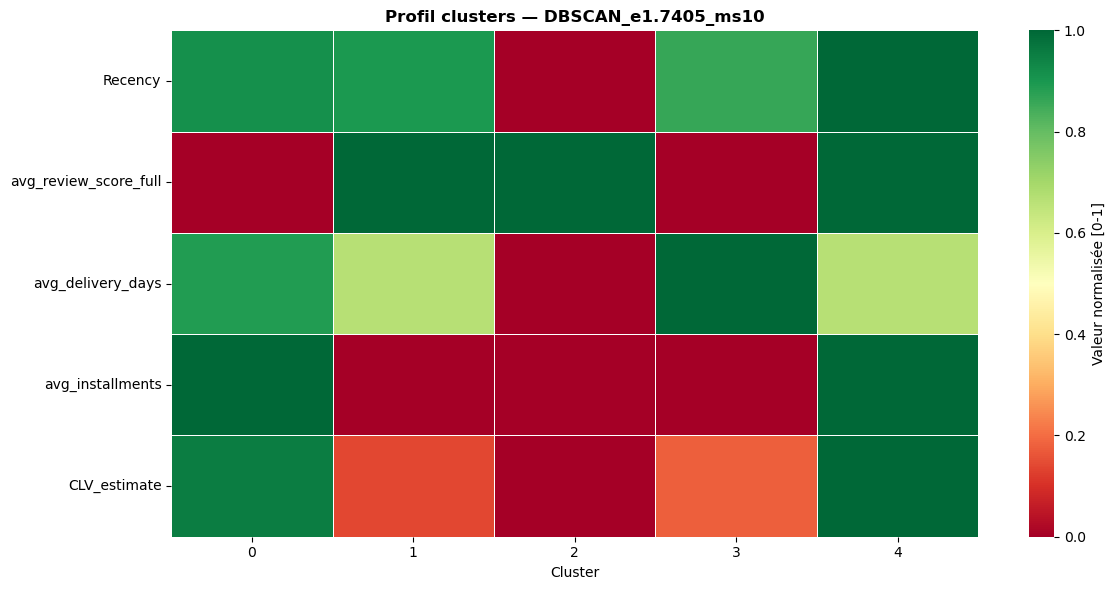


DISTRIBUTION DES SEGMENTS

C0 — Dormants Satisfaits
   Taille : 17,999 (19.3%)
   ▓▓▓▓▓▓▓▓▓
   Action : Campagne de réactivation ciblée

C1 — Clients Déçus
   Taille : 23,951 (25.7%)
   ▓▓▓▓▓▓▓▓▓▓▓▓
   Action : Suivi SAV et amélioration livraison

C2 — Acheteurs Standard
   Taille : 9,793 (10.5%)
   ▓▓▓▓▓
   Action : Cross-selling et programme fidélité

C3 — Premium Fidèles
   Taille : 17,126 (18.3%)
   ▓▓▓▓▓▓▓▓▓
   Action : Programme VIP et offres exclusives

C4 — Cluster 4
   Taille : 24,489 (26.2%)
   ▓▓▓▓▓▓▓▓▓▓▓▓▓
   Action : Analyse complémentaire

✅ Exports réalisés
📁 reports/cluster_profiles.csv
📁 reports/df_client_clustered.csv

✅ SECTION PROFILING TERMINÉE


In [16]:
# ============================================================
# SECTION 13 — PROFILING & NOMMAGE DES SEGMENTS
# ============================================================

print("\n" + "=" * 70)
print("PROFILING DES CLUSTERS")
print("=" * 70)

# ============================================================
# DATAFRAME CLUSTERISÉ
# ============================================================

df_clean = client_df[FEATURES_ACTIVE].copy()

df_clean["cluster"] = labels_final

# ============================================================
# PROFIL MÉDIAN
# ============================================================

profile = (

    df_clean
    .groupby("cluster")[FEATURES_ACTIVE]
    .median()
    .round(3)

)

# ============================================================
# AFFICHAGE
# ============================================================

print("\n📊 PROFILS MÉDIANS\n")

display(profile)

# ============================================================
# NORMALISATION
# ============================================================

prof_norm = (

    profile - profile.min()

) / (

    profile.max()

    - profile.min()

    + 1e-9
)

# ============================================================
# HEATMAP
# ============================================================

fig_height = max(

    6,

    len(FEATURES_ACTIVE) * 0.45
)

fig, ax = plt.subplots(

    figsize=(12, fig_height)

)

sns.heatmap(

    prof_norm.T,

    cmap="RdYlGn",

    linewidths=0.4,

    ax=ax,

    annot=False,

    cbar_kws={
        "label": "Valeur normalisée [0-1]"
    }
)

ax.set_title(

    f"Profil clusters — {BEST_MODEL_NAME}",

    fontweight="bold"
)

ax.set_xlabel("Cluster")

plt.tight_layout()

plt.savefig(

    "figures/11_profil_heatmap.png",

    dpi=120,

    bbox_inches="tight"
)

plt.show()

plt.close()

# ============================================================
# NOMS DES SEGMENTS
# ============================================================

# ------------------------------------------------------------
# EXEMPLE PAR DÉFAUT
# À ADAPTER APRÈS ANALYSE
# ------------------------------------------------------------

SEGMENT_NAMES = {

    0: "Dormants Satisfaits",

    1: "Clients Déçus",

    2: "Acheteurs Standard",

    3: "Premium Fidèles",

}

# ============================================================
# ACTIONS MARKETING
# ============================================================

SEGMENT_ACTIONS = {

    "Dormants Satisfaits":

        "Campagne de réactivation ciblée",

    "Clients Déçus":

        "Suivi SAV et amélioration livraison",

    "Acheteurs Standard":

        "Cross-selling et programme fidélité",

    "Premium Fidèles":

        "Programme VIP et offres exclusives"
}

# ============================================================
# DISTRIBUTION DES CLUSTERS
# ============================================================

print("\n" + "=" * 70)
print("DISTRIBUTION DES SEGMENTS")
print("=" * 70)

for cid in sorted(profile.index):

    # --------------------------------------------------------
    # NOM
    # --------------------------------------------------------

    sname = SEGMENT_NAMES.get(
        cid,
        f"Cluster {cid}"
    )

    # --------------------------------------------------------
    # EFFECTIF
    # --------------------------------------------------------

    n = int(
        (labels_final == cid).sum()
    )

    pct = (
        n / len(labels_final)
    ) * 100

    # --------------------------------------------------------
    # BARRE
    # --------------------------------------------------------

    bar = "▓" * int(pct / 2)

    # --------------------------------------------------------
    # ACTION
    # --------------------------------------------------------

    action = SEGMENT_ACTIONS.get(
        sname,
        "Analyse complémentaire"
    )

    # --------------------------------------------------------
    # AFFICHAGE
    # --------------------------------------------------------

    print(
        f"\nC{cid} — {sname}"
    )

    print(
        f"   Taille : "
        f"{n:,} ({pct:.1f}%)"
    )

    print(
        f"   {bar}"
    )

    print(
        f"   Action : {action}"
    )

# ============================================================
# AJOUT LABELS MÉTIER
# ============================================================

df_clean["segment_name"] = (

    df_clean["cluster"]
    .map(SEGMENT_NAMES)
)

# ============================================================
# EXPORTS
# ============================================================

profile.to_csv(

    "reports/cluster_profiles.csv"
)

df_clean.to_csv(

    "reports/df_client_clustered.csv",

    index=False
)

print("\n✅ Exports réalisés")

print(
    "📁 reports/cluster_profiles.csv"
)

print(
    "📁 reports/df_client_clustered.csv"
)

# ============================================================
# MÉMOIRE
# ============================================================

gc.collect()

print("\n✅ SECTION PROFILING TERMINÉE")


VISUALISATION t-SNE

🎨 t-SNE sur 2,500 points...

✅ t-SNE calculé


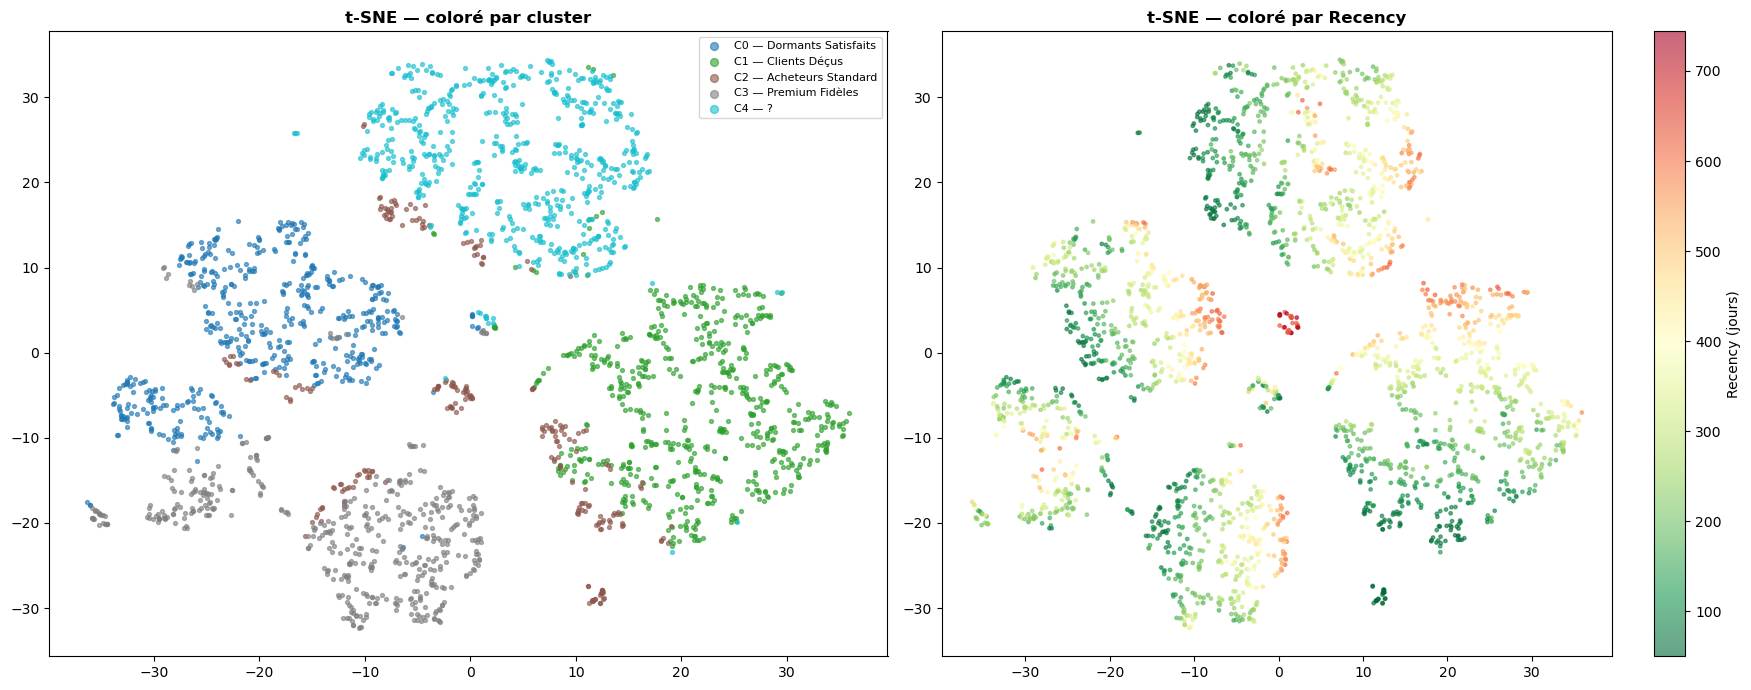


✅ SECTION t-SNE TERMINÉE


In [17]:
# ============================================================
# SECTION 14 — t-SNE OPTIMISÉ
# ============================================================

print("\n" + "=" * 70)
print("VISUALISATION t-SNE")
print("=" * 70)

# ============================================================
# ÉCHANTILLON t-SNE
# ============================================================

N_TSNE = min(
    2500,
    len(X_pca)
)

rng_ts = np.random.default_rng(
    RANDOM_STATE + 5
)

idx_ts = rng_ts.choice(
    len(X_pca),
    N_TSNE,
    replace=False
)

print(
    f"\n🎨 t-SNE sur "
    f"{N_TSNE:,} points..."
)

# ============================================================
# DONNÉES
# ============================================================

X_ts_input = X_pca[idx_ts]

lbs_ts = labels_final[idx_ts]

# ============================================================
# t-SNE
# ============================================================

tsne = TSNE(

    n_components=2,

    perplexity=30,

    max_iter=500,

    init="pca",

    learning_rate="auto",

    random_state=RANDOM_STATE
)

X_tsne = tsne.fit_transform(
    X_ts_input
)

print("\n✅ t-SNE calculé")

# ============================================================
# FIGURE
# ============================================================

fig, axes = plt.subplots(

    1,
    2,

    figsize=(18, 7)
)

# ============================================================
# COLORMAP
# ============================================================

cmap_t = cm.get_cmap(
    "tab10",
    K_FINAL
)

# ============================================================
# PLOT CLUSTERS
# ============================================================

unique_ts = sorted(
    set(lbs_ts)
)

for i, lbl in enumerate(unique_ts):

    mask = lbs_ts == lbl

    col = (
        "lightgray"
        if lbl == -1
        else cmap_t(i)
    )

    name = (

        "Bruit"

        if lbl == -1

        else f"C{lbl} — "
             f"{SEGMENT_NAMES.get(lbl,'?')}"
    )

    axes[0].scatter(

        X_tsne[mask, 0],

        X_tsne[mask, 1],

        c=[col],

        s=8,

        alpha=0.6,

        label=name
    )

axes[0].set_title(

    "t-SNE — coloré par cluster",

    fontweight="bold"
)

axes[0].legend(

    markerscale=2,

    fontsize=8
)

# ============================================================
# COLORATION RECENCY
# ============================================================

recency_ts = client_df.iloc[idx_ts][
    "Recency"
].values

sc = axes[1].scatter(

    X_tsne[:, 0],

    X_tsne[:, 1],

    c=recency_ts,

    cmap="RdYlGn_r",

    s=6,

    alpha=0.6
)

axes[1].set_title(

    "t-SNE — coloré par Recency",

    fontweight="bold"
)

plt.colorbar(

    sc,

    ax=axes[1],

    label="Recency (jours)"
)

# ============================================================
# GLOBAL
# ============================================================

plt.tight_layout()

plt.savefig(

    "figures/12_tsne.png",

    dpi=100,

    bbox_inches="tight"
)

plt.show()

plt.close()

# ============================================================
# MÉMOIRE
# ============================================================

del X_ts_input
del X_tsne

gc.collect()

print("\n✅ SECTION t-SNE TERMINÉE")


INTERPRÉTABILITÉ SHAP

🌲 Entraînement RandomForest...

Accuracy train : 0.9730
Accuracy test  : 0.9700

✅ Échantillon SHAP : 500

🧠 Calcul SHAP...

📐 Shape SHAP :
(500, 5, 5)

✅ SHAP calculé

📊 Calcul importance globale...
Shape détectée : (500, 5, 5)

✅ Importance SHAP calculée


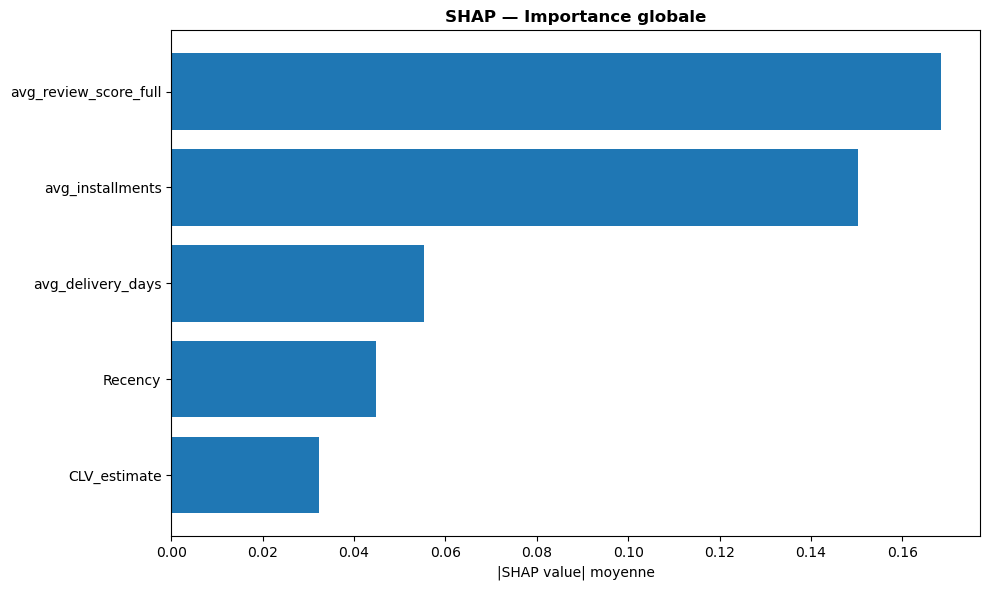


✅ Importance SHAP exportée

🏆 TOP VARIABLES CLUSTERING



,feature,shap_importance
1,avg_review_score_full,0.1686
3,avg_installments,0.1504
2,avg_delivery_days,0.0553
0,Recency,0.0447
4,CLV_estimate,0.0324



🎨 SHAP summary plot...


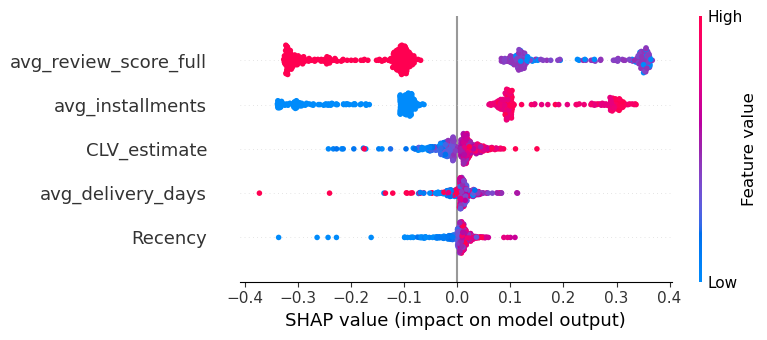


✅ Summary plot généré

🌊 Waterfall plots...


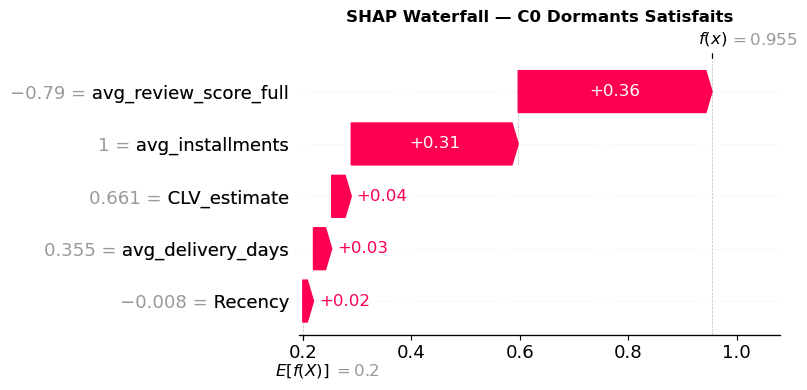

   ✅ Waterfall C0


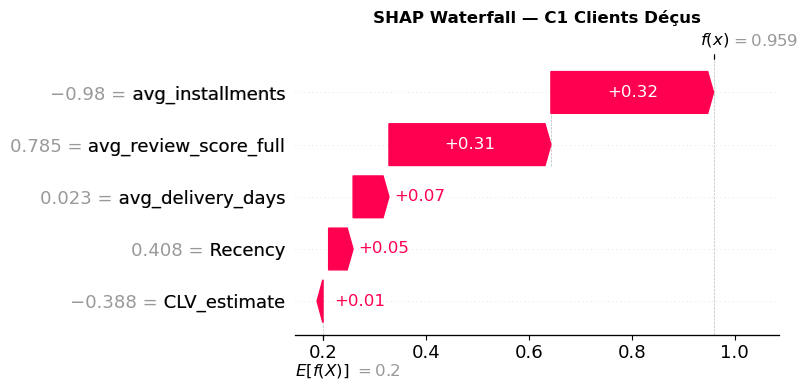

   ✅ Waterfall C1

✅ SECTION SHAP TERMINÉE


In [18]:
# ============================================================
# SECTION 15 — SHAP OPTIMISÉ (VERSION CORRIGÉE)
# ============================================================

print("\n" + "=" * 70)
print("INTERPRÉTABILITÉ SHAP")
print("=" * 70)

# ============================================================
# DONNÉES RANDOM FOREST
# ============================================================

X_rf = X_scaled.values

y_rf = labels_final.copy()

# ------------------------------------------------------------
# RETRAIT DU BRUIT (-1)
# ------------------------------------------------------------

mask_valid = y_rf != -1

X_rf = X_rf[mask_valid]

y_rf = y_rf[mask_valid]

# ============================================================
# TRAIN / TEST SPLIT
# ============================================================

X_tr, X_te, y_tr, y_te = train_test_split(

    X_rf,

    y_rf,

    test_size=0.2,

    stratify=y_rf,

    random_state=RANDOM_STATE
)

# ============================================================
# RANDOM FOREST SURROGATE
# ============================================================

print("\n🌲 Entraînement RandomForest...")

rf = RandomForestClassifier(

    n_estimators=120,

    max_depth=8,

    min_samples_leaf=30,

    class_weight="balanced",

    random_state=RANDOM_STATE,

    n_jobs=-1
)

rf.fit(X_tr, y_tr)

# ============================================================
# SCORES
# ============================================================

train_acc = rf.score(X_tr, y_tr)

test_acc = rf.score(X_te, y_te)

print(
    f"\nAccuracy train : "
    f"{train_acc:.4f}"
)

print(
    f"Accuracy test  : "
    f"{test_acc:.4f}"
)

# ============================================================
# SAUVEGARDE RANDOM FOREST
# ============================================================

joblib.dump(

    rf,

    "models/rf_surrogate.pkl"
)

# ============================================================
# ÉCHANTILLON SHAP
# ============================================================

N_SHAP = min(
    500,
    len(X_te)
)

rng_sh = np.random.default_rng(
    RANDOM_STATE + 2
)

idx_sh = rng_sh.choice(

    len(X_te),

    N_SHAP,

    replace=False
)

X_shap = X_te[idx_sh]

y_te_sh = y_te[idx_sh]

print(
    f"\n✅ Échantillon SHAP : "
    f"{N_SHAP}"
)

# ============================================================
# SHAP EXPLAINER
# ============================================================

print("\n🧠 Calcul SHAP...")

explainer = shap.TreeExplainer(rf)

shap_vals = explainer.shap_values(
    X_shap
)

# ============================================================
# DEBUG SHAPE
# ============================================================

print("\n📐 Shape SHAP :")

print(
    np.array(shap_vals).shape
)

# ============================================================
# SAUVEGARDE EXPLAINER
# ============================================================

joblib.dump(

    explainer,

    "models/shap_explainer.pkl"
)

print("\n✅ SHAP calculé")

# ============================================================
# IMPORTANCE GLOBALE SHAP
# ============================================================

print("\n📊 Calcul importance globale...")

# ------------------------------------------------------------
# FORMAT LISTE
# ------------------------------------------------------------

if isinstance(shap_vals, list):

    shap_array = np.array(
        shap_vals
    )

    # shape :
    # (n_classes, n_samples, n_features)

    shap_global = np.abs(

        shap_array

    ).mean(axis=(0, 1))

# ------------------------------------------------------------
# FORMAT ARRAY 3D
# ------------------------------------------------------------

else:

    shap_array = np.array(
        shap_vals
    )

    print(
        f"Shape détectée : "
        f"{shap_array.shape}"
    )

    # --------------------------------------------------------
    # CAS :
    # (n_samples, n_features, n_classes)
    # --------------------------------------------------------

    if shap_array.shape[1] == len(FEATURES_ACTIVE):

        shap_global = np.abs(

            shap_array

        ).mean(axis=(0, 2))

    # --------------------------------------------------------
    # CAS :
    # (n_classes, n_samples, n_features)
    # --------------------------------------------------------

    else:

        shap_global = np.abs(

            shap_array

        ).mean(axis=(0, 1))

# ============================================================
# DATAFRAME IMPORTANCE
# ============================================================

shap_df = pd.DataFrame({

    "feature": FEATURES_ACTIVE,

    "shap_importance": shap_global

})

# ------------------------------------------------------------
# TRI
# ------------------------------------------------------------

shap_df = shap_df.sort_values(

    "shap_importance",

    ascending=False
)

print("\n✅ Importance SHAP calculée")

# ============================================================
# BARPLOT IMPORTANCE
# ============================================================

fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.barh(

    shap_df["feature"],

    shap_df["shap_importance"]
)

ax.invert_yaxis()

ax.set_title(

    "SHAP — Importance globale",

    fontweight="bold"
)

ax.set_xlabel(
    "|SHAP value| moyenne"
)

plt.tight_layout()

plt.savefig(

    "figures/13_shap_global.png",

    dpi=120,

    bbox_inches="tight"
)

plt.show()

plt.close()

# ============================================================
# EXPORT
# ============================================================

shap_df.to_csv(

    "reports/shap_importance.csv",

    index=False
)

print("\n✅ Importance SHAP exportée")

# ============================================================
# TOP VARIABLES
# ============================================================

print("\n🏆 TOP VARIABLES CLUSTERING\n")

display(

    shap_df
    .head(10)
    .round(4)

)

# ============================================================
# SUMMARY PLOT
# ============================================================

print("\n🎨 SHAP summary plot...")

# ------------------------------------------------------------
# PREMIÈRE CLASSE SI MULTICLASSE
# ------------------------------------------------------------

if isinstance(shap_vals, list):

    shap_plot_values = shap_vals[0]

else:

    shap_array = np.array(shap_vals)

    # cas (n_samples, n_features, n_classes)
    if shap_array.shape[1] == len(FEATURES_ACTIVE):

        shap_plot_values = shap_array[:, :, 0]

    # cas (n_classes, n_samples, n_features)
    else:

        shap_plot_values = shap_array[0]

# ------------------------------------------------------------
# SUMMARY PLOT
# ------------------------------------------------------------

shap.summary_plot(

    shap_plot_values,

    X_shap,

    feature_names=FEATURES_ACTIVE,

    show=False
)

plt.tight_layout()

plt.savefig(

    "figures/13b_shap_summary.png",

    dpi=120,

    bbox_inches="tight"
)

plt.show()

plt.close()

print("\n✅ Summary plot généré")

# ============================================================
# WATERFALL PLOTS
# ============================================================

print("\n🌊 Waterfall plots...")

unique_c = sorted(

    np.unique(y_te_sh)
)

# ------------------------------------------------------------
# MAXIMUM 2 CLUSTERS
# ------------------------------------------------------------

for cid in unique_c[:2]:

    mask_c = y_te_sh == cid

    if mask_c.sum() == 0:

        continue

    # --------------------------------------------------------
    # DONNÉES CLUSTER
    # --------------------------------------------------------

    Xc = X_shap[mask_c]

    # --------------------------------------------------------
    # SHAP VALUES CLUSTER
    # --------------------------------------------------------

    if isinstance(shap_vals, list):

        sv_c = shap_vals[cid][mask_c]

        base_val = explainer.expected_value[cid]

    else:

        shap_array = np.array(shap_vals)

        # --------------------------------------------
        # CAS :
        # (n_samples, n_features, n_classes)
        # --------------------------------------------

        if shap_array.shape[1] == len(FEATURES_ACTIVE):

            sv_c = shap_array[mask_c, :, cid]

        # --------------------------------------------
        # CAS :
        # (n_classes, n_samples, n_features)
        # --------------------------------------------

        else:

            sv_c = shap_array[cid][mask_c]

        # expected value
        if isinstance(explainer.expected_value, np.ndarray):

            base_val = explainer.expected_value[cid]

        else:

            base_val = explainer.expected_value

    # --------------------------------------------------------
    # CLIENT REPRÉSENTATIF
    # --------------------------------------------------------

    centroid = Xc.mean(axis=0)

    repr_i = np.argmin(

        np.linalg.norm(
            Xc - centroid,
            axis=1
        )
    )

    # --------------------------------------------------------
    # EXPLANATION
    # --------------------------------------------------------

    exp = shap.Explanation(

        values=sv_c[repr_i],

        base_values=base_val,

        data=Xc[repr_i],

        feature_names=FEATURES_ACTIVE
    )

    # --------------------------------------------------------
    # WATERFALL
    # --------------------------------------------------------

    shap.plots.waterfall(

        exp,

        max_display=8,

        show=False
    )

    plt.title(

        f"SHAP Waterfall — "
        f"C{cid} "
        f"{SEGMENT_NAMES.get(cid,'')}",

        fontweight="bold"
    )

    plt.tight_layout()

    plt.savefig(

        f"figures/13c_shap_waterfall_C{cid}.png",

        dpi=120,

        bbox_inches="tight"
    )

    plt.show()

    plt.close()

    print(
        f"   ✅ Waterfall C{cid}"
    )

# ============================================================
# LIBÉRATION MÉMOIRE
# ============================================================

gc.collect()

print("\n✅ SECTION SHAP TERMINÉE")


INTERPRÉTABILITÉ LIME

🧠 Construction LIME explainer...

✅ LIME explainer construit

------------------------------------------------------------
C0 — Dormants Satisfaits
------------------------------------------------------------
Confiance : 95.0%

Top variables :
  ⬆ avg_review_score_full <= -0.79                +0.7102
  ⬆ 0.02 < avg_delivery_days <= 0.53              +0.0443
  ⬆ 0.01 < Recency <= 0.56                        +0.0343
  ⬆ 0.00 < CLV_estimate <= 0.57                   +0.0332
  ⬆ 0.62 < avg_installments <= 0.79               +0.0263

------------------------------------------------------------
C1 — Clients Déçus
------------------------------------------------------------
Confiance : 96.2%

Top variables :
  ⬆ -0.79 < avg_review_score_full <= 0.78         +0.1043
  ⬆ 0.01 < Recency <= 0.56                        +0.0293
  ⬇ -0.56 < CLV_estimate <= 0.00                  -0.0176
  ⬇ -0.58 < avg_delivery_days <= 0.02             -0.0167
  ⬆ avg_installments <= -0.98    

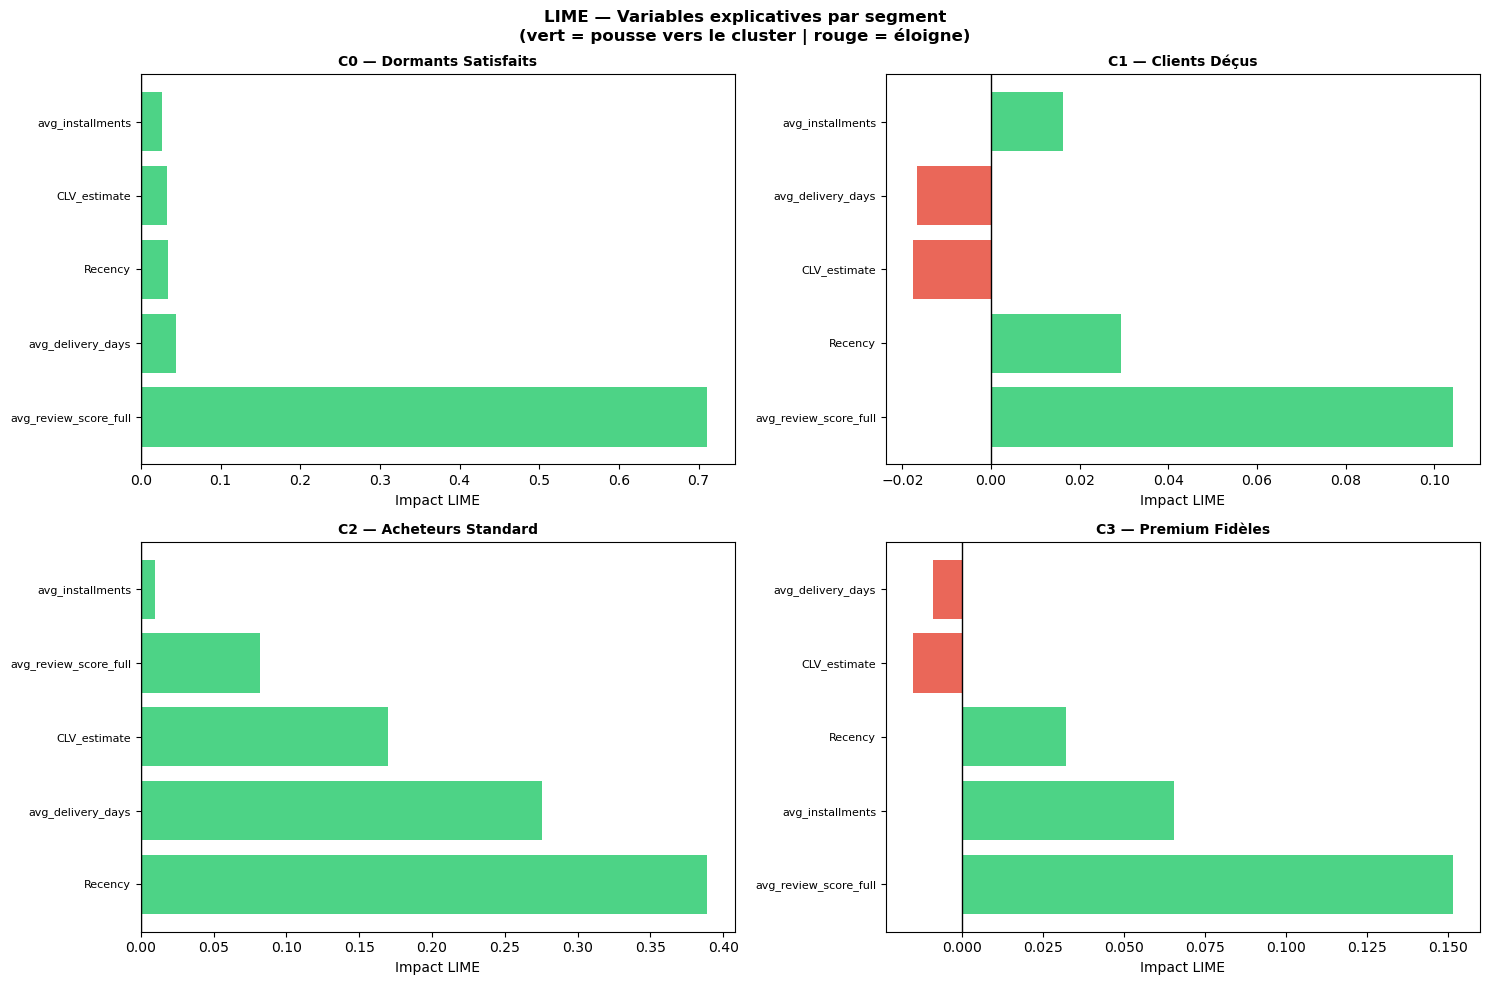


✅ Résumé LIME exporté
📁 reports/lime_summary.txt
📁 reports/lime_summary.json

✅ SECTION LIME TERMINÉE


In [19]:
# ============================================================
# SECTION 16 — LIME OPTIMISÉ (CORRIGÉ)
# ============================================================

print("\n" + "=" * 70)
print("INTERPRÉTABILITÉ LIME")
print("=" * 70)

# ============================================================
# LIME EXPLAINER
# ============================================================

print("\n🧠 Construction LIME explainer...")

lime_explainer = lime.lime_tabular.LimeTabularExplainer(

    training_data=X_tr,

    feature_names=FEATURES_ACTIVE,

    class_names=[

        SEGMENT_NAMES.get(i, f"C{i}")

        for i in range(K_FINAL)
    ],

    mode="classification",

    discretize_continuous=True,

    discretizer="quartile",

    random_state=RANDOM_STATE
)

print("\n✅ LIME explainer construit")

# ============================================================
# FIGURE
# ============================================================

N_CLUSTERS_SHOW = min(
    4,
    K_FINAL
)

fig, axes = plt.subplots(

    2,
    2,

    figsize=(15, 10)
)

axes = axes.flatten()

# ============================================================
# STOCKAGE
# ============================================================

lime_summaries = {}

# ============================================================
# BOUCLE CLUSTERS
# ============================================================

for i, cid in enumerate(

    sorted(SEGMENT_NAMES.keys())[:N_CLUSTERS_SHOW]
):

    print("\n" + "-" * 60)

    print(
        f"C{cid} — "
        f"{SEGMENT_NAMES[cid]}"
    )

    print("-" * 60)

    # --------------------------------------------------------
    # DONNÉES CLUSTER
    # --------------------------------------------------------

    mask_c = y_tr == cid

    X_tr_c = X_tr[mask_c]

    if len(X_tr_c) == 0:

        continue

    # --------------------------------------------------------
    # CLIENT REPRÉSENTATIF
    # --------------------------------------------------------

    centroid = X_tr_c.mean(axis=0)

    repr_idx = np.argmin(

        np.linalg.norm(
            X_tr_c - centroid,
            axis=1
        )
    )

    x_repr = X_tr_c[repr_idx]

    # --------------------------------------------------------
    # EXPLICATION LIME
    # --------------------------------------------------------

    lime_exp = lime_explainer.explain_instance(

        data_row=x_repr,

        predict_fn=rf.predict_proba,

        num_features=8,

        num_samples=1000,

        labels=[cid]
    )

    # --------------------------------------------------------
    # FEATURES
    # --------------------------------------------------------

    feats = lime_exp.as_list(
        label=cid
    )

    lime_summaries[cid] = feats

    # ========================================================
    # EXTRACTION FEATURES
    # ========================================================

    names_l = []

    weights_l = []

    for rule, w in feats:

        found = False

        for feat in FEATURES_ACTIVE:

            if feat in rule:

                names_l.append(feat)

                found = True

                break

        if not found:

            names_l.append(
                rule[:25]
            )

        weights_l.append(w)

    # ========================================================
    # COULEURS
    # ========================================================

    colors_l = [

        "#2ecc71"

        if w > 0

        else "#e74c3c"

        for w in weights_l
    ]

    # ========================================================
    # BARPLOT
    # ========================================================

    axes[i].barh(

        range(len(names_l)),

        weights_l,

        color=colors_l,

        alpha=0.85
    )

    axes[i].set_yticks(

        range(len(names_l))
    )

    axes[i].set_yticklabels(

        names_l,

        fontsize=8
    )

    axes[i].axvline(

        0,

        color="black",

        lw=1
    )

    axes[i].set_title(

        f"C{cid} — "
        f"{SEGMENT_NAMES[cid]}",

        fontweight="bold",

        fontsize=10
    )

    axes[i].set_xlabel(
        "Impact LIME"
    )

    # ========================================================
    # CONFIANCE
    # ========================================================

    proba = rf.predict_proba(
        [x_repr]
    )[0]

    print(
        f"Confiance : "
        f"{proba[cid]:.1%}"
    )

    print("\nTop variables :")

    for feat_rule, w in feats[:5]:

        direction = (

            "⬆"

            if w > 0

            else "⬇"
        )

        print(
            f"  {direction} "
            f"{feat_rule:<45} "
            f"{w:+.4f}"
        )

# ============================================================
# SUPPRESSION AXES VIDES
# ============================================================

for j in range(i + 1, len(axes)):

    fig.delaxes(axes[j])

# ============================================================
# GLOBAL FIGURE
# ============================================================

plt.suptitle(

    "LIME — Variables explicatives par segment\n"
    "(vert = pousse vers le cluster | rouge = éloigne)",

    fontweight="bold",

    fontsize=12
)

plt.tight_layout()

plt.savefig(

    "figures/14_lime_comparaison.png",

    dpi=120,

    bbox_inches="tight"
)

plt.show()

plt.close()

# ============================================================
# EXPORT TEXTE
# ============================================================

with open(

    "reports/lime_summary.txt",

    "w",

    encoding="utf-8"

) as f:

    for cid, feats in lime_summaries.items():

        f.write(
            f"\n=== "
            f"C{cid} — "
            f"{SEGMENT_NAMES[cid]} "
            f"===\n"
        )

        for feat_rule, w in feats:

            f.write(
                f"{feat_rule:<60} "
                f"{w:+.4f}\n"
            )

print("\n✅ Résumé LIME exporté")

print(
    "📁 reports/lime_summary.txt"
)

# ============================================================
# EXPORT JSON
# ============================================================

import json

lime_json = {}

for cid, feats in lime_summaries.items():

    lime_json[str(cid)] = [

        {

            "rule": rule,

            "weight": float(weight)

        }

        for rule, weight in feats
    ]

with open(

    "reports/lime_summary.json",

    "w",

    encoding="utf-8"

) as f:

    json.dump(

        lime_json,

        f,

        indent=4,

        ensure_ascii=False
    )

print(
    "📁 reports/lime_summary.json"
)

# ============================================================
# MÉMOIRE
# ============================================================

gc.collect()

print("\n✅ SECTION LIME TERMINÉE")


STABILITÉ TEMPORELLE DES SEGMENTS

⚠️ Pas de variable temporelle

--------------------------------------------------
Période : 0
--------------------------------------------------
ARI = 1.0000 (référence)

--------------------------------------------------
Période : 1
--------------------------------------------------
ARI = 0.0001

--------------------------------------------------
Période : 2
--------------------------------------------------
ARI = -0.0003

--------------------------------------------------
Période : 3
--------------------------------------------------
ARI = -0.0001

--------------------------------------------------
Période : 4
--------------------------------------------------
ARI = 0.0003

--------------------------------------------------
Période : 5
--------------------------------------------------
ARI = -0.0001

RÉSULTATS STABILITÉ
0 : ARI=1.0000 ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
1 : ARI=0.0001 
2 : ARI=-0.0003 
3 : ARI=-0.0001 
4 : ARI=0.0003 
5 : ARI=-0.0001 



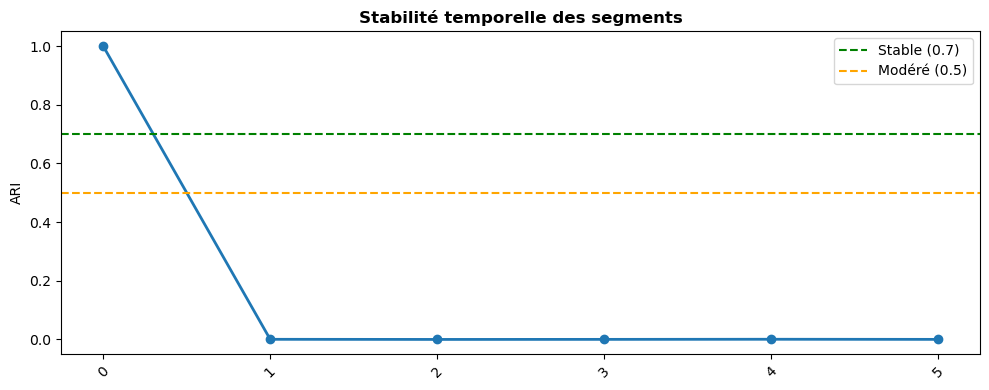


✅ Export réalisé
📁 reports/ari_stabilite.csv

✅ SECTION STABILITÉ TERMINÉE


In [20]:
# ============================================================
# SECTION 17 — STABILITÉ TEMPORELLE (ARI)
# ============================================================

print("\n" + "=" * 70)
print("STABILITÉ TEMPORELLE DES SEGMENTS")
print("=" * 70)

# ============================================================
# COLONNE TEMPORELLE
# ============================================================

if "order_purchase_timestamp" in client_df.columns:

    client_df["purchase_date"] = pd.to_datetime(

        client_df["order_purchase_timestamp"]
    )

    client_df["year_month"] = (

        client_df["purchase_date"]

        .dt.to_period("M")
    )

    periods = sorted(

        client_df["year_month"].unique()

    )[-6:]

    print(
        f"\n📅 Analyse sur "
        f"{len(periods)} périodes"
    )

else:

    # --------------------------------------------------------
    # SIMULATION
    # --------------------------------------------------------

    n = len(client_df)

    periods = list(range(6))

    client_df["year_month"] = np.repeat(

        periods,

        [

            n // 6

            +

            (

                1

                if i < n % 6

                else 0
            )

            for i in range(6)
        ]

    )[:n]

    print(
        "\n⚠️ Pas de variable temporelle"
    )

# ============================================================
# PARAMÈTRES
# ============================================================

N_STAB = 5000

rng_stab = np.random.default_rng(
    RANDOM_STATE + 100
)

ari_scores = []

labels_ref = None

# ============================================================
# BOUCLE PÉRIODES
# ============================================================

for period in periods:

    print("\n" + "-" * 50)

    print(
        f"Période : {period}"
    )

    print("-" * 50)

    # --------------------------------------------------------
    # INDEX PÉRIODE
    # --------------------------------------------------------

    idx_p = client_df[
        client_df["year_month"] == period
    ].index.tolist()

    # --------------------------------------------------------
    # TAILLE MINIMALE
    # --------------------------------------------------------

    if len(idx_p) < 300:

        print(
            "⚠ période ignorée"
        )

        continue

    # --------------------------------------------------------
    # ÉCHANTILLON
    # --------------------------------------------------------

    if len(idx_p) > N_STAB:

        idx_p = rng_stab.choice(

            idx_p,

            N_STAB,

            replace=False
        )

    # --------------------------------------------------------
    # DONNÉES PCA
    # --------------------------------------------------------

    X_p = X_pca[idx_p]

    # --------------------------------------------------------
    # KMEANS RAPIDE
    # --------------------------------------------------------

    km_p = KMeans(

        n_clusters=K_FINAL,

        init="k-means++",

        n_init=5,

        max_iter=200,

        random_state=RANDOM_STATE
    )

    lbs_p = km_p.fit_predict(
        X_p
    )

    # --------------------------------------------------------
    # PREMIÈRE PÉRIODE
    # --------------------------------------------------------

    if labels_ref is None:

        labels_ref = lbs_p.copy()

        ari_scores.append(1.0)

        print(
            "ARI = 1.0000 (référence)"
        )

    # --------------------------------------------------------
    # ARI
    # --------------------------------------------------------

    else:

        n_min = min(

            len(labels_ref),

            len(lbs_p)
        )

        ari = adjusted_rand_score(

            labels_ref[:n_min],

            lbs_p[:n_min]
        )

        ari_scores.append(
            ari
        )

        print(
            f"ARI = {ari:.4f}"
        )

        labels_ref = lbs_p.copy()

    # --------------------------------------------------------
    # LIBÉRATION
    # --------------------------------------------------------

    del X_p
    del lbs_p

    gc.collect()

# ============================================================
# RÉSULTATS
# ============================================================

print("\n" + "=" * 70)

print("RÉSULTATS STABILITÉ")

print("=" * 70)

for p, ari in zip(periods, ari_scores):

    bar = "▓" * int(
        ari * 30
    )

    print(
        f"{p} : "
        f"ARI={ari:.4f} "
        f"{bar}"
    )

# ============================================================
# ARI MOYEN
# ============================================================

ari_mean = np.mean(
    ari_scores
)

print("\n" + "=" * 70)

print(
    f"ARI moyen : "
    f"{ari_mean:.4f}"
)

print("=" * 70)

# ============================================================
# INTERPRÉTATION
# ============================================================

if ari_mean > 0.7:

    stability_msg = (

        "✅ Segments très stables — "
        "mise à jour trimestrielle recommandée"
    )

elif ari_mean > 0.5:

    stability_msg = (

        "⚠️ Stabilité modérée — "
        "mise à jour mensuelle recommandée"
    )

else:

    stability_msg = (

        "❌ Segments instables — "
        "revoir les variables"
    )

print("\n" + stability_msg)

# ============================================================
# VISUALISATION
# ============================================================

plt.figure(
    figsize=(10, 4)
)

plt.plot(

    range(len(ari_scores)),

    ari_scores,

    marker="o",

    lw=2
)

plt.axhline(

    0.7,

    color="green",

    ls="--",

    lw=1.5,

    label="Stable (0.7)"
)

plt.axhline(

    0.5,

    color="orange",

    ls="--",

    lw=1.5,

    label="Modéré (0.5)"
)

plt.xticks(

    range(len(periods)),

    [str(p) for p in periods],

    rotation=45
)

plt.ylabel("ARI")

plt.title(

    "Stabilité temporelle des segments",

    fontweight="bold"
)

plt.legend()

plt.tight_layout()

plt.savefig(

    "figures/15_ari_stabilite.png",

    dpi=100,

    bbox_inches="tight"
)

plt.show()

plt.close()

# ============================================================
# EXPORT
# ============================================================

df_ari = pd.DataFrame({

    "period": periods,

    "ari": ari_scores
})

df_ari.to_csv(

    "reports/ari_stabilite.csv",

    index=False
)

print("\n✅ Export réalisé")

print(
    "📁 reports/ari_stabilite.csv"
)

# ============================================================
# MÉMOIRE
# ============================================================

gc.collect()

print("\n✅ SECTION STABILITÉ TERMINÉE")

In [21]:
# ============================================================
# SECTION 18 — PIPELINE API OPTIMISÉ
# ============================================================

print("\n" + "=" * 70)
print("PIPELINE API — PRÉDICTION CLIENT")
print("=" * 70)

# ============================================================
# IMPORTANCE RF GLOBALE
# ============================================================

rf_importances = pd.DataFrame({

    "feature": FEATURES_ACTIVE,

    "importance": rf.feature_importances_
})

rf_importances = rf_importances.sort_values(

    "importance",

    ascending=False
)

TOP_GLOBAL_FEATURES = rf_importances[
    "feature"
].tolist()

# ============================================================
# FONCTION PRÉDICTION
# ============================================================

def predict_segment(raw_features: dict) -> dict:

    """
    Pipeline complet de segmentation client
    """

    # --------------------------------------------------------
    # 1. MISE EN FORME
    # --------------------------------------------------------

    x = np.array([

        [

            raw_features.get(f, 0)

            for f in FEATURES_ACTIVE
        ]

    ], dtype="float32")

    # --------------------------------------------------------
    # 2. QUANTILE TRANSFORM
    # --------------------------------------------------------

    x_qt = qt.transform(x)

    # --------------------------------------------------------
    # 3. STANDARD SCALER
    # --------------------------------------------------------

    x_sc = scaler.transform(x_qt)

    # --------------------------------------------------------
    # 4. PCA
    # --------------------------------------------------------

    x_pca_new = pca_final.transform(x_sc)

    # --------------------------------------------------------
    # 5. CLUSTER
    # --------------------------------------------------------

    if hasattr(model_final, "predict"):

        cluster_id = int(

            model_final.predict(
                x_pca_new
            )[0]
        )

    else:

        cluster_id = int(

            model_final.fit_predict(
                x_pca_new
            )[0]
        )

    # --------------------------------------------------------
    # 6. PROBABILITÉS RF
    # --------------------------------------------------------

    proba = rf.predict_proba(
        x_sc
    )[0]

    confidence = float(
        proba[cluster_id]
    )

    # --------------------------------------------------------
    # 7. TOP FEATURES CLIENT
    # --------------------------------------------------------

    client_feature_impacts = []

    for feat in TOP_GLOBAL_FEATURES[:6]:

        idx_feat = FEATURES_ACTIVE.index(
            feat
        )

        val = float(
            x[0][idx_feat]
        )

        client_feature_impacts.append({

            "feature": feat,

            "value": round(val, 3),

            "importance": round(

                float(

                    rf_importances.loc[
                        rf_importances["feature"] == feat,
                        "importance"
                    ].values[0]
                ),

                4
            )
        })

    # --------------------------------------------------------
    # 8. SEGMENT
    # --------------------------------------------------------

    segment_name = SEGMENT_NAMES.get(

        cluster_id,

        f"C{cluster_id}"
    )

    # --------------------------------------------------------
    # 9. ACTION MARKETING
    # --------------------------------------------------------

    action = SEGMENT_ACTIONS.get(

        segment_name,

        "Standard"
    )

    # --------------------------------------------------------
    # 10. SORTIE
    # --------------------------------------------------------

    result = {

        "cluster": cluster_id,

        "segment": segment_name,

        "action": action,

        "confidence": confidence,

        "probabilities": {

            SEGMENT_NAMES.get(i, f"C{i}"):

            round(float(p), 4)

            for i, p in enumerate(proba)
        },

        "top_features": client_feature_impacts
    }

    return result

# ============================================================
# TESTS API
# ============================================================

print("\n🧪 TESTS PIPELINE API")

# ============================================================
# CAS TEST
# ============================================================

test_cases = {

    "Client Dormant": {

        "Recency": 300,

        "Frequency": 1,

        "Monetary": 90,

        "avg_review_score_full": 5,

        "avg_delivery_days": 9,

        "avg_installments": 1,

        "product_diversity": 1,

        "avg_order_value": 50,

        "avg_basket_size": 1,

        "CLV_estimate": 80,

        "inter_purchase_time": 200,

        "recency_ratio": 0.8
    },

    "Client Premium": {

        "Recency": 30,

        "Frequency": 5,

        "Monetary": 1200,

        "avg_review_score_full": 5,

        "avg_delivery_days": 4,

        "avg_installments": 8,

        "product_diversity": 6,

        "avg_order_value": 300,

        "avg_basket_size": 4,

        "CLV_estimate": 2500,

        "inter_purchase_time": 20,

        "recency_ratio": 0.1
    }
}

# ============================================================
# BOUCLE TESTS
# ============================================================

for name, features in test_cases.items():

    res = predict_segment(
        features
    )

    print("\n" + "=" * 60)

    print(
        f"{name}"
    )

    print("=" * 60)

    print(
        f"Segment : "
        f"C{res['cluster']} "
        f"— "
        f"{res['segment']}"
    )

    print(
        f"Confiance : "
        f"{res['confidence']:.1%}"
    )

    print(
        f"Action : "
        f"{res['action']}"
    )

    # --------------------------------------------------------
    # PROBABILITÉS
    # --------------------------------------------------------

    print("\nProbabilités :")

    for seg, p in res["probabilities"].items():

        bar = "▓" * int(
            p * 25
        )

        print(
            f"  {seg:<25} "
            f"{p:.1%} "
            f"{bar}"
        )

    # --------------------------------------------------------
    # FEATURES
    # --------------------------------------------------------

    print("\nTop variables :")

    for ft in res["top_features"][:5]:

        print(
            f"  • {ft['feature']:<25} "
            f"val={ft['value']:<10} "
            f"importance={ft['importance']:.4f}"
        )

# ============================================================
# EXPORT PIPELINE
# ============================================================

pipeline_objects = {

    "qt": qt,

    "scaler": scaler,

    "pca": pca_final,

    "model": model_final,

    "rf": rf,

    "features": FEATURES_ACTIVE,

    "segment_names": SEGMENT_NAMES,

    "segment_actions": SEGMENT_ACTIONS
}

joblib.dump(

    pipeline_objects,

    "models/pipeline_complete.pkl"
)

print("\n✅ Pipeline complet sauvegardé")

print(
    "📁 models/pipeline_complete.pkl"
)

# ============================================================
# MÉMOIRE
# ============================================================

gc.collect()

print("\n✅ SECTION API TERMINÉE")


PIPELINE API — PRÉDICTION CLIENT

🧪 TESTS PIPELINE API

Client Dormant
Segment : C3 — Premium Fidèles
Confiance : 26.3%
Action : Programme VIP et offres exclusives

Probabilités :
  Dormants Satisfaits       0.3% 
  Clients Déçus             70.2% ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  Acheteurs Standard        1.8% 
  Premium Fidèles           26.3% ▓▓▓▓▓▓
  C4                        1.4% 

Top variables :
  • avg_review_score_full     val=5.0        importance=0.3455
  • avg_installments          val=1.0        importance=0.3143
  • avg_delivery_days         val=9.0        importance=0.1658
  • Recency                   val=300.0      importance=0.1175
  • CLV_estimate              val=80.0       importance=0.0569

Client Premium
Segment : C2 — Acheteurs Standard
Confiance : 63.5%
Action : Cross-selling et programme fidélité

Probabilités :
  Dormants Satisfaits       11.6% ▓▓
  Clients Déçus             0.1% 
  Acheteurs Standard        63.5% ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  Premium Fidèles           0.0% 
  C4    

In [22]:
# ============================================================
# SECTION 19 — RÉSUMÉ FINAL
# ============================================================

print("\n" + "=" * 70)
print("RÉSUMÉ FINAL — SEGMENTATION OLIST")
print("=" * 70)

# ============================================================
# SAUVEGARDE DES OBJETS STABLES
# ============================================================

print("\n💾 Sauvegarde des objets...")

artifacts = {

    "quantile_transformer": qt,

    "scaler": scaler,

    "pca_final": pca_final,

    "model_final": model_final,

    "rf_surrogate": rf
}

# ------------------------------------------------------------
# SAUVEGARDE
# ------------------------------------------------------------

for name, obj in artifacts.items():

    try:

        joblib.dump(

            obj,

            f"models/{name}.pkl"
        )

        print(
            f"   ✅ {name}.pkl"
        )

    except Exception as e:

        print(
            f"   ❌ {name} : {e}"
        )

# ============================================================
# PIPELINE COMPLET
# ============================================================

pipeline_complete = {

    "qt": qt,

    "scaler": scaler,

    "pca": pca_final,

    "model": model_final,

    "rf": rf,

    "features": FEATURES_ACTIVE,

    "segment_names": SEGMENT_NAMES,

    "segment_actions": SEGMENT_ACTIONS
}

try:

    joblib.dump(

        pipeline_complete,

        "models/pipeline_complete.pkl"
    )

    print(
        "\n✅ pipeline_complete.pkl sauvegardé"
    )

except Exception as e:

    print(
        f"\n❌ Erreur pipeline : {e}"
    )

# ============================================================
# RÉSUMÉ MODÈLE
# ============================================================

print("\n" + "=" * 70)

print(
    "MODÈLE FINAL"
)

print("=" * 70)

print(
    f"🏆 Modèle retenu : "
    f"{BEST_MODEL_NAME}"
)

print(
    f"📌 Nombre de segments : "
    f"{K_FINAL}"
)

# ============================================================
# SCORES
# ============================================================

best_row = df_r.iloc[0]

print("\n📊 Performances")

print(
    f"   Silhouette       : "
    f"{best_row['silhouette']:.4f}"
)

print(
    f"   Davies-Bouldin   : "
    f"{best_row['davies_bouldin']:.4f}"
)

print(
    f"   Score composite  : "
    f"{best_row['score']:.4f}"
)

# ============================================================
# SEGMENTS
# ============================================================

print("\n👥 Segments identifiés")

for cid, sname in sorted(
    SEGMENT_NAMES.items()
):

    n = int(
        (labels_final == cid).sum()
    )

    pct = (
        n / len(labels_final)
    ) * 100

    bar = "▓" * int(
        pct / 2
    )

    print(

        f"\nC{cid} — "
        f"{sname}"

    )

    print(
        f"   Taille : "
        f"{n:,} ({pct:.1f}%)"
    )

    print(
        f"   {bar}"
    )

    print(
        f"   Action : "
        f"{SEGMENT_ACTIONS.get(sname, 'Standard')}"
    )

# ============================================================
# PIPELINE API
# ============================================================

print("\n" + "=" * 70)

print(
    "PIPELINE API"
)

print("=" * 70)

print(
    "\nraw_features"
)

print(
    "   ↓"
)

print(
    "QuantileTransformer"
)

print(
    "   ↓"
)

print(
    "StandardScaler"
)

print(
    "   ↓"
)

print(
    f"PCA ({N_COMP} composantes)"
)

print(
    "   ↓"
)

print(
    BEST_MODEL_NAME
)

print(
    "   ↓"
)

print(
    "Segment marketing"
)

# ============================================================
# DOSSIER MODELS
# ============================================================

print("\n" + "=" * 70)

print(
    "FICHIERS SAUVEGARDÉS"
)

print("=" * 70)

model_files = sorted(

    os.listdir("models")
)

for f in model_files:

    size_mb = (

        os.path.getsize(
            os.path.join("models", f)
        )

        /

        (1024 * 1024)
    )

    print(
        f"📦 {f:<35} "
        f"{size_mb:.2f} MB"
    )

# ============================================================
# RAPPORTS
# ============================================================

print("\n" + "=" * 70)

print(
    "RAPPORTS GÉNÉRÉS"
)

print("=" * 70)

if os.path.exists("reports"):

    for f in sorted(

        os.listdir("reports")
    ):

        print(
            f"📄 {f}"
        )

# ============================================================
# FIGURES
# ============================================================

print("\n" + "=" * 70)

print(
    "FIGURES GÉNÉRÉES"
)

print("=" * 70)

if os.path.exists("figures"):

    figs = sorted(

        os.listdir("figures")
    )

    print(
        f"\n🖼️ {len(figs)} figures générées"
    )

    for f in figs[:10]:

        print(
            f"   • {f}"
        )

    if len(figs) > 10:

        print(
            f"   ... +{len(figs)-10} autres"
        )

# ============================================================
# MLFLOW
# ============================================================

print("\n" + "=" * 70)

print(
    "MLFLOW"
)

print("=" * 70)

print(
    "\n🚀 Lancer MLflow :"
)

print(
    "   mlflow ui --port 5000"
)

print(
    "\n🌐 Interface :"
)

print(
    "   http://localhost:5000"
)

# ============================================================
# CONCLUSION
# ============================================================

print("\n" + "=" * 70)

print(
    "CONCLUSION"
)

print("=" * 70)

print(
    "\n✅ Pipeline de segmentation terminé"
)

print(
    "✅ Modèle sauvegardé"
)

print(
    "✅ Pipeline API prêt"
)

print(
    "✅ Interprétabilité SHAP/LIME réalisée"
)

print(
    "✅ Stabilité temporelle analysée"
)

print(
    "✅ Projet prêt pour GitHub / soutenance"
)

# ============================================================
# MÉMOIRE
# ============================================================

gc.collect()

print("\n✅ FIN DU NOTEBOOK")


RÉSUMÉ FINAL — SEGMENTATION OLIST

💾 Sauvegarde des objets...
   ✅ quantile_transformer.pkl
   ✅ scaler.pkl
   ✅ pca_final.pkl
   ✅ model_final.pkl
   ✅ rf_surrogate.pkl

✅ pipeline_complete.pkl sauvegardé

MODÈLE FINAL
🏆 Modèle retenu : DBSCAN_e1.7405_ms10
📌 Nombre de segments : 5

📊 Performances
   Silhouette       : 0.4223
   Davies-Bouldin   : 0.7459
   Score composite  : 0.6222

👥 Segments identifiés

C0 — Dormants Satisfaits
   Taille : 17,999 (19.3%)
   ▓▓▓▓▓▓▓▓▓
   Action : Campagne de réactivation ciblée

C1 — Clients Déçus
   Taille : 23,951 (25.7%)
   ▓▓▓▓▓▓▓▓▓▓▓▓
   Action : Suivi SAV et amélioration livraison

C2 — Acheteurs Standard
   Taille : 9,793 (10.5%)
   ▓▓▓▓▓
   Action : Cross-selling et programme fidélité

C3 — Premium Fidèles
   Taille : 17,126 (18.3%)
   ▓▓▓▓▓▓▓▓▓
   Action : Programme VIP et offres exclusives

PIPELINE API

raw_features
   ↓
QuantileTransformer
   ↓
StandardScaler
   ↓
PCA (4 composantes)
   ↓
DBSCAN_e1.7405_ms10
   ↓
Segment marketing

FICHI